Catalog loaded. Total samples: 1102
Starting calculation of effective attenuation curves for each Age/Flux-Ratio bin...

Processing Bin 0: Flux Ratio 0.0 - 0.51


/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


  - Dust Group 6 is empty.


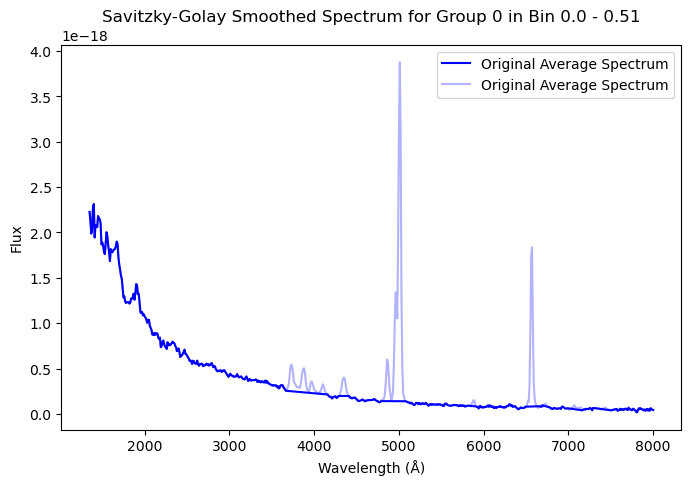

  > Successfully computed effective curve using 5 dust groups.

Processing Bin 1: Flux Ratio 0.51 - 0.72


/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


  - Dust Group 6 is empty.


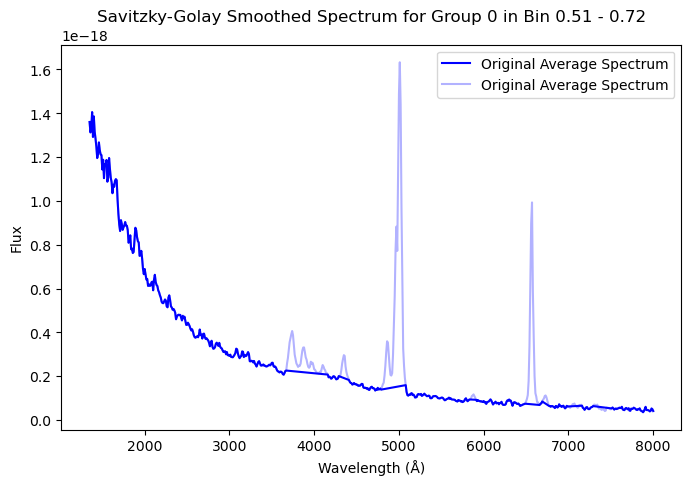

  > Successfully computed effective curve using 5 dust groups.

Processing Bin 2: Flux Ratio 0.72 - 1.5


/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


  - Dust Group 6 is empty.


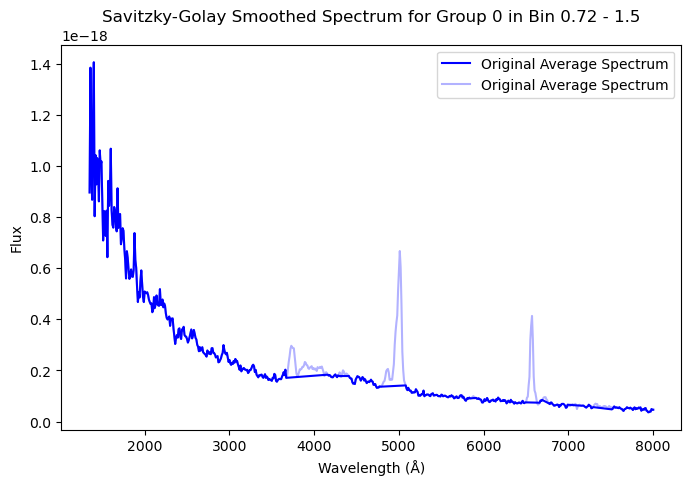

  > Successfully computed effective curve using 5 dust groups.

Calculation Complete. 'effective_attenuation_curve_list' is ready.


In [2]:
from curses import window
import numpy as np
import pandas as pd
import FunctionLib as FL
import astropy.units as u
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from tqdm.notebook import tqdm # 使用 notebook 版本的进度条
import matplotlib.pyplot as plt


# ==========================================
# 1. 加载数据与定义分组标准
# ==========================================

# 加载 Catalog (请确保路径正确)
DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl('./DJAV4.2Catalog.pkl')
print(f"Catalog loaded. Total samples: {DJAv4Catalog.sample_num()}")

# 定义分组 (完全参照 File 16)
# Dn Index (Flux Ratio) 分组: 年轻(蓝) -> 年老(红)
dn_index_conditions = np.array([[0, 0.51], [0.51, 0.72], [0.72, 1.5]])

# Balmer Decrement (Dust) 分组: 依据 ln(Ha/Hb / 2.86)
group_conditions = [(-0.05, 0.02), (0.02, 0.10), (0.10, 0.2), (0.2, 0.3), (0.3, 0.45), (0.45, 0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return -1 # 超出范围

def dn_condition_func(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions):
        if low < dn_index <= high:
            return i
    return -1

# ==========================================
# 2. 核心计算循环：生成 Q 曲线列表
# ==========================================
POWER_LAW_FIT_GROUP0 = True  # 是否对 Group 0 进行 Power Law 拟合

effective_attenuation_curve_list = []

print("Starting calculation of effective attenuation curves for each Age/Flux-Ratio bin...")

# 遍历每一个 Flux Ratio (Age) 分组
for dn_bin_index in range(len(dn_index_conditions)):

    bin_label = f"{dn_index_conditions[dn_bin_index][0]} - {dn_index_conditions[dn_bin_index][1]}"
    print(f"\nProcessing Bin {dn_bin_index}: Flux Ratio {bin_label}")

    # 1. 初始化 Averagers (0-6组, 0为参考组)
    # 使用字典管理，比 globals() 更安全
    averagers = {i: FL.SpectrumAverager() for i in range(7)}

    # 用于存储每组的平均 Balmer Decrement (用于计算 Delta Tau)
    group_decrement_values = {i: [] for i in range(7)}

    # 2. 遍历 Catalog，将星系填入对应的 Averager
    # 注意：为了效率，我们在这里进行单次遍历筛选
    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue

        # 获取 Flux Ratio
        try:
            measurements = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
            dn_index = measurements['red_flux_density'] / measurements['blue_flux_density']
        except KeyError:
            continue

        # 检查是否属于当前的 Flux Ratio Bin
        if dn_condition_func(dn_index) != dn_bin_index:
            continue

        # 获取 Balmer Decrement 并确定尘埃组
        try:
            lines = entry['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']
            halpha = lines['halpha_flux']
            hbeta = lines['hbeta_flux']
            if hbeta <= 0: continue

            balmer_decrement = np.log(halpha / hbeta / 2.86)
            group_idx = group_condition_func(balmer_decrement)

            if group_idx != -1:
                # 加载光谱到对应的 Averager
                # 这里假设 load_spectrum_catalog 只需要 ID 和 Catalog 对象
                # 并且内部调用 Load_Spectrum_From_Fits
                averagers[group_idx].load_spectrum_catalog(
                    [surveyid_subid],
                    DJAv4Catalog,
                    load_func=FL.Load_Spectrum_From_Fits # 显式传入加载函数
                )
                group_decrement_values[group_idx].append(balmer_decrement)

        except Exception as e:
            continue

    # 3. 计算每组的平均光谱 (Stacking)
    invalid_averager = np.zeros(7, dtype=bool)
    group_mean_decrement = {}

    for i in range(7):
        # 计算平均 Balmer Decrement
        if len(group_decrement_values[i]) > 0:
            group_mean_decrement[i] = np.mean(group_decrement_values[i])
        else:
            group_mean_decrement[i] = 0
            invalid_averager[i] = True
            print(f"  - Dust Group {i} is empty.")
            continue

        # 处理光谱
        try:
            averagers[i].create_common_wavelength_grid(wavelength_range=(1350, 8000), grid_size=10)
            averagers[i].interpolate_spectra(interpolation_method='linear')
            # 归一化范围 (5250-5750 A)
            averagers[i].spectrum_normalization_within_range(wavelength_range=(5250, 5750), target_flux=1e-19)
            # 计算平均 (Median stacking)
            averagers[i].compute_average_spectrum(method='median', ignore_nan=True,
                                                 use_percentile_filter=True,
                                                 lower_percentile=16, upper_percentile=84)
        except Exception as e:
            print(f"  - Error processing Group {i}: {e}")
            invalid_averager[i] = True

    # 4. 强制 Group 0 的 Balmer Decrement 为基准 (设为0或者相对值)
    # File 16 的逻辑是：group_decrement_list[0]=0
    # 这意味着我们计算的是相对于 Group 0 的额外尘埃
    group_mean_decrement[0] = 0.0

    # 4a. 使用 Power Law 拟合 Group 0 的平均光谱 (可选)
    if POWER_LAW_FIT_GROUP0 := True:
        x=averagers[0].common_wavelength
        y=averagers[0].average_flux
        window_len = 101
        poly_order = 4


        series_curve = pd.Series(y, index=x)
        curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')
        curve_clean = curve_clean.to_numpy()

        sg_smooth = savgol_filter(curve_clean, window_length=window_len, polyorder=poly_order)

        mask_regions = [
        (3675, 4150), (4300, 4400), (4800, 5075),
        (5850, 5900), (6500, 6650), (6700, 6760),
        (7000, 7150), (7300, 7500)
    ]

        mask=np.ones_like(x, dtype=bool)
        for (low, high) in mask_regions:
            low, high = float(low), float(high)
            mask &= ~((x >= low) & (x <= high))

        valid_data=np.isfinite(sg_smooth) & np.isfinite(x) & mask

        x_fit = x[valid_data]
        y_fit = y[valid_data]
        averagers[0].average_flux = sg_smooth
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot(x[valid_data], y[valid_data], label='Original Average Spectrum', color='blue')
        ax.plot(x, y, label='Original Average Spectrum', color='blue', alpha=0.3)
        # ax.plot(x[valid_data], sg_smooth[valid_data], label='Savitzky-Golay Smoothed', color='red', linestyle='--')
        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Flux')
        ax.set_title(f'Savitzky-Golay Smoothed Spectrum for Group 0 in Bin {bin_label}')
        ax.legend()
        plt.show()


    # 5. 计算 Q_lambda (相对于 Group 0)
    if invalid_averager[0]:
        print("  ! Critical Error: Reference Group 0 is empty. Cannot compute curves for this bin.")
        # 填充空数据以保持列表长度一致，防止报错
        dummy_wave = np.linspace(1350, 8000, 666)
        effective_attenuation_curve_list.append((dummy_wave, np.full_like(dummy_wave, np.nan)))
        continue

    ref_flux = averagers[0].average_flux
    Q_lambda_list = []
    valid_weights = []

    # 只需要计算 Group 1 到 5 (或者到6，取决于是否有数据)
    for i in range(1, 6):
        if invalid_averager[i]:
            continue

        target_flux = averagers[i].average_flux

        # 计算光学深度 Tau
        # 忽略除零错误
        with np.errstate(divide='ignore', invalid='ignore'):
            tau_lambda = -np.log(target_flux / ref_flux)

        # 计算 Delta Tau (Balmer)
        delta_tau_balmer = group_mean_decrement[i] - group_mean_decrement[0]

        if delta_tau_balmer > 0.01: # 避免除以极小值
            Q_lambda = tau_lambda / delta_tau_balmer
            Q_lambda_list.append(Q_lambda)
            valid_weights.append(delta_tau_balmer) # 权重为 delta tau

    # 6. 计算加权平均的 Effective Curve
    if len(Q_lambda_list) > 0:
        Q_lambda_array = np.array(Q_lambda_list)
        # 使用 Masked Array 处理 NaN
        Q_lambda_masked = np.ma.masked_invalid(Q_lambda_array)

        effective_curve = np.ma.average(Q_lambda_masked, axis=0, weights=valid_weights).filled(np.nan)
        common_wave = averagers[0].common_wavelength

        effective_attenuation_curve_list.append((common_wave, effective_curve))
        print(f"  > Successfully computed effective curve using {len(Q_lambda_list)} dust groups.")
    else:
        print("  ! No valid dust groups to compute effective curve.")
        dummy_wave = np.linspace(1350, 8000, 666)
        effective_attenuation_curve_list.append((dummy_wave, np.full_like(dummy_wave, np.nan)))

print("\nCalculation Complete. 'effective_attenuation_curve_list' is ready.")

Bin Range       | Measured Rv     | Slope (Flatness)
--------------------------------------------------
0.0 - 0.51      | 8.7006          | Flat
0.51 - 0.72     | 6.9676          | Flat
0.72 - 1.5      | 5.9113          | Flat


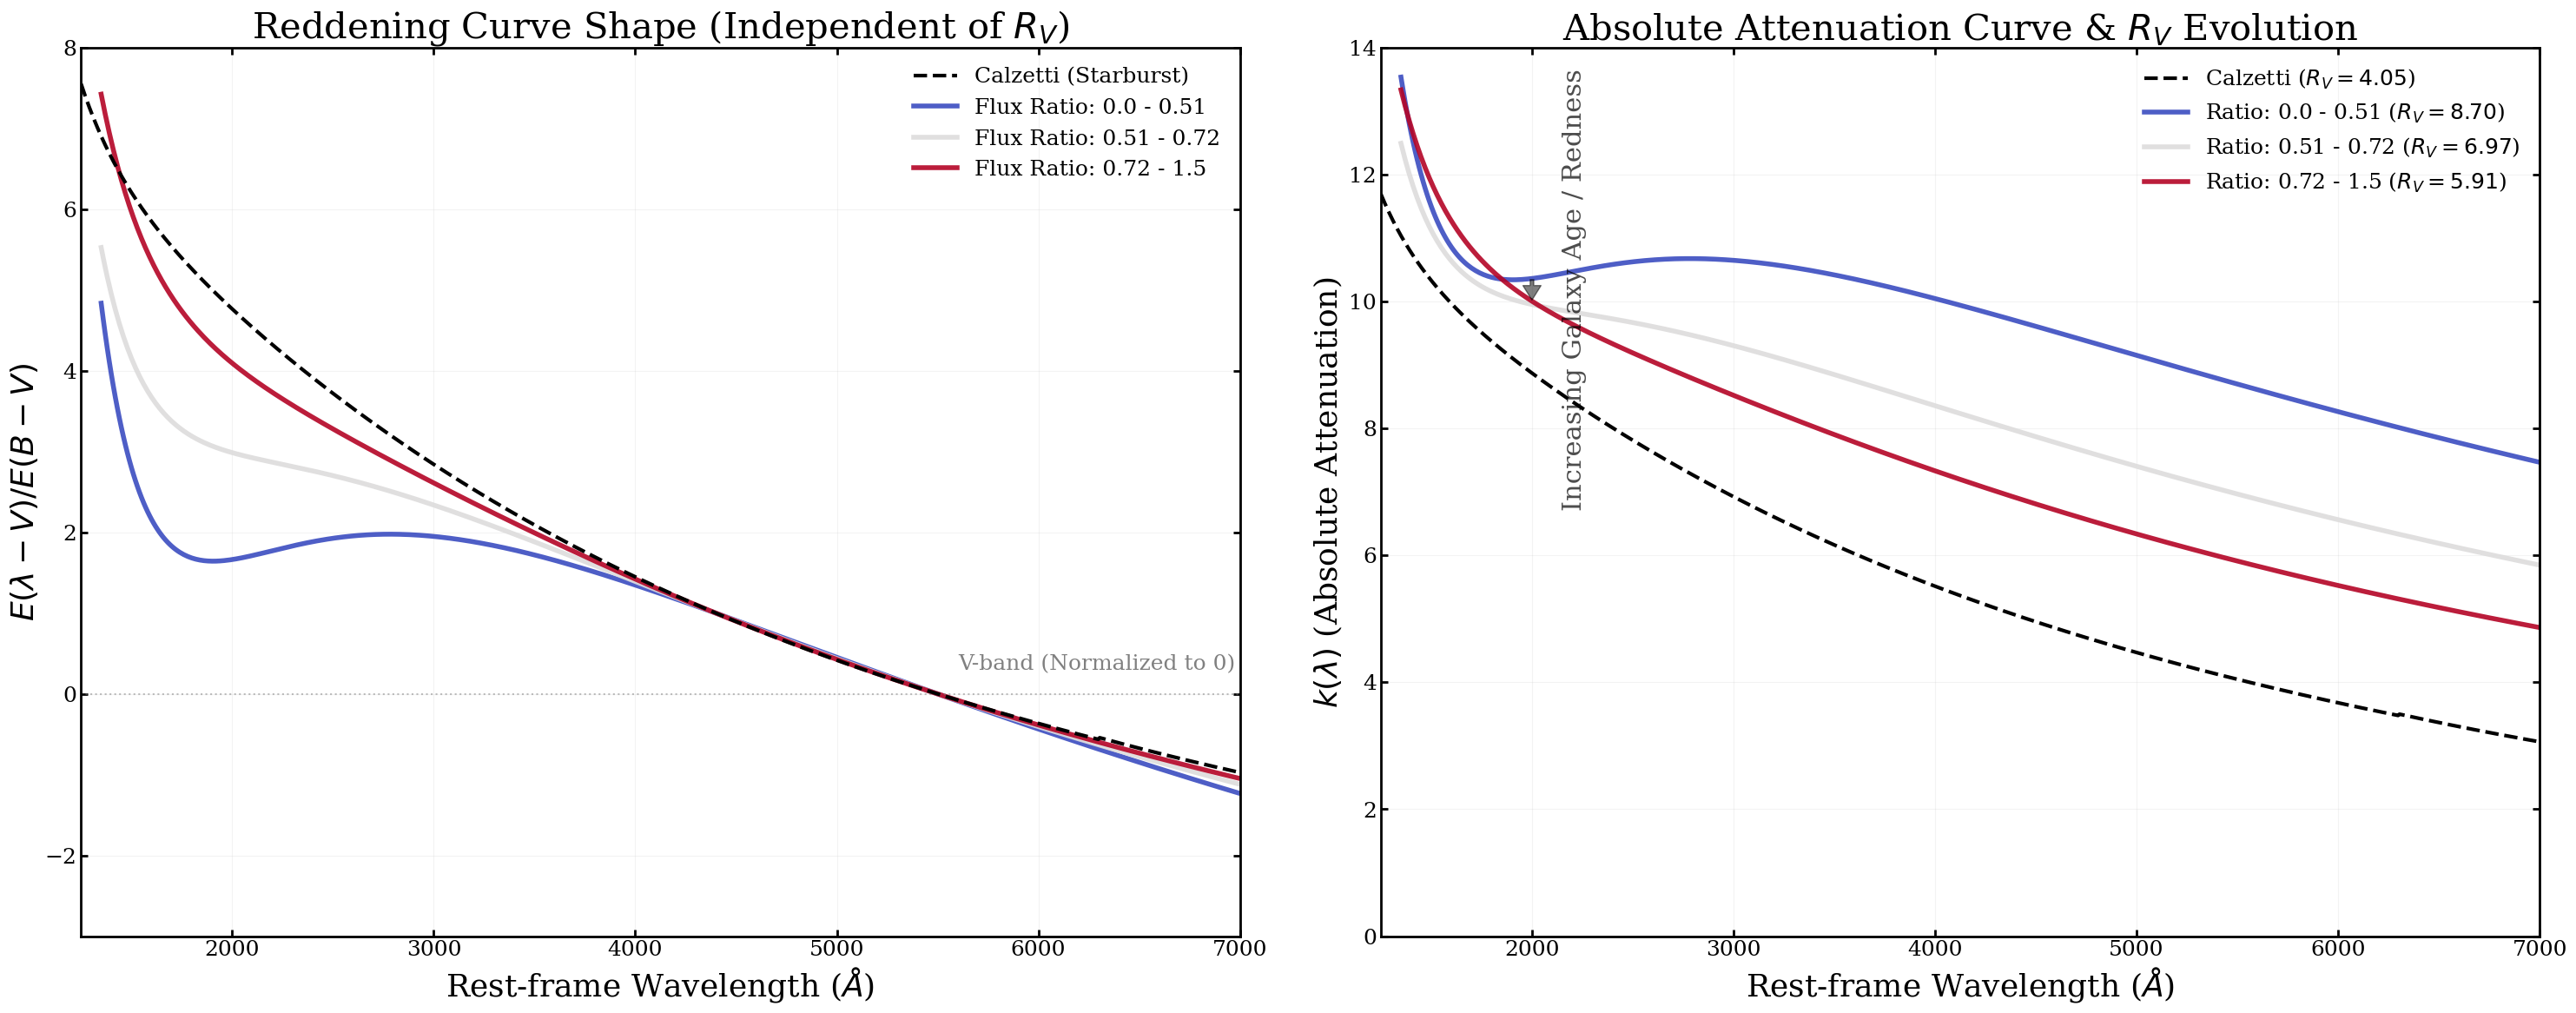

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

# ==========================================
# 1. 设置绘图风格 (Publication Quality)
# ==========================================
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.linewidth': 2,
    'xtick.major.size': 6,
    'xtick.major.width': 2,
    'ytick.major.size': 6,
    'ytick.major.width': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.figsize': (28, 12)
})

# ==========================================
# 2. 定义核心物理函数 (无需外部依赖)
# ==========================================

def calzetti_2000_law(lam_angstroms, Rv=4.05):
    """
    Calzetti (2000) Attenuation Law k(lambda).
    """
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)

    # Range 1: 0.12um to 0.63um
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv

    # Range 2: 0.63um to 2.2um
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv

    return k

def poly_model_inverse(lam_micron, a, b, c, d):
    """
    Polynomial model based on 1/lambda.
    k(x) = a + b*x + c*x^2 + d*x^3, where x = 1/lambda(micron)
    """
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

def get_calzetti_shape_normalized(wave_angstrom):
    """
    Return shape E(l-V)/E(B-V) for Calzetti law.
    """
    k_cal = calzetti_2000_law(wave_angstrom, Rv=4.05)

    # Interpolate to find precise B and V values
    k_B = np.interp(4400, wave_angstrom, k_cal)
    k_V = np.interp(5500, wave_angstrom, k_cal)

    # Definition: (k(l) - k(V)) / (k(B) - k(V))
    # For standard Calzetti, denominator is 1.0 by definition
    return (k_cal - k_V) / (k_B - k_V)

# ==========================================
# 3. 数据处理与拟合 (Data Processing)
# ==========================================

results = []
# 生成颜色映射：从蓝色(Flux Ratio小)到红色(Flux Ratio大)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(dn_index_conditions)))

print(f"{'Bin Range':<15} | {'Measured Rv':<15} | {'Slope (Flatness)'}")
print("-" * 50)

for i in range(len(dn_index_conditions)):
    # 1. 获取数据 (假设 effective_attenuation_curve_list 存在于环境中)
    # 格式: (wavelength_array, Q_value_array)
    wave, Q_curve = effective_attenuation_curve_list[i]

    # 2. 预处理：Mask 掉发射线区域和 NaN
    mask_regions = [
        (3700, 4150), (4300, 4400), (4800, 5050),
        (5850, 5900), (6500, 6650), (6700, 6760),
        (7000, 7150), (7300, 7500)
    ]

    is_continuum = np.ones_like(wave, dtype=bool)
    for start, end in mask_regions:
        is_continuum &= ~((wave >= start) & (wave <= end))

    valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
    # 只拟合 1250A 到 8000A
    fit_mask = (wave > 1250) & (wave < 8000) & is_continuum & valid_data

    # 3. 拟合 Q(lambda)
    microns = wave / 10000.0
    try:
        popt, _ = curve_fit(poly_model_inverse, microns[fit_mask], Q_curve[fit_mask])
    except:
        print(f"Fit failed for bin {i}")
        continue

    # 4. 计算归一化因子 (Scaling Factor S)
    # 依据: k(B) - k(V) = 1
    # k = S * Q + C
    # S * (Q_B - Q_V) = 1  => S = 1 / (Q_B - Q_V)
    Q_B = poly_model_inverse(0.4400, *popt)
    Q_V = poly_model_inverse(0.5500, *popt)
    delta_tau = Q_B - Q_V
    S_factor = 1.0 / delta_tau

    # 5. 计算零点漂移 (Zero-point Shift C)
    # 依据: 强制无穷远处的消光 k(inf) = -0.8877 (匹配 Calzetti 远红端渐近线)
    # 多项式在 x=1/inf=0 处的值为 popt[0] (常数项 a)
    # k(inf) = S * Q(inf) + C = S * a + C = -0.8877
    # C = -0.8877 - S * a
    a_intercept = popt[0]
    C_shift = -0.8877 - (a_intercept * S_factor)

    # 6. 生成最终曲线
    # 为了画图平滑，使用全波长范围，不带噪声
    Q_smooth = poly_model_inverse(microns, *popt)
    k_final = Q_smooth * S_factor + C_shift

    # 7. 计算 Rv
    # Rv = k(V)
    Rv_measured = k_final[(np.abs(wave - 5500)).argmin()]

    # 8. 计算红化形状 (Reddening Curve Shape)
    # Shape = k(lambda) - Rv
    shape_curve = k_final - Rv_measured

    bin_label = f"{dn_index_conditions[i][0]} - {dn_index_conditions[i][1]}"
    print(f"{bin_label:<15} | {Rv_measured:.4f}          | {'Steep' if Rv_measured < 4 else 'Flat'}")

    results.append({
        'wave': wave,
        'k_final': k_final,
        'shape_curve': shape_curve,
        'Rv': Rv_measured,
        'label': bin_label,
        'color': colors[i]
    })

# ==========================================
# 4. 绘图 (Visualization)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
plt.subplots_adjust(wspace=0.15)

# --- 生成参考线数据 ---
x_grid = np.linspace(1250, 8000, 1000)
calzetti_shape = get_calzetti_shape_normalized(x_grid)
calzetti_k = calzetti_2000_law(x_grid, Rv=4.05)

# ------------------------------------------
# 图 1 (左): 红化形状 (Reddening Curve Shape)
# ------------------------------------------
ax0 = axes[0]

# 画参考线
ax0.plot(x_grid, calzetti_shape, color='black', linestyle='--', linewidth=3,
         label='Calzetti (Starburst)', zorder=10)

# 画各组数据
for res in results:
    mask_plot = (res['wave'] > 1250) & (res['wave'] < 7000)
    ax0.plot(res['wave'][mask_plot], res['shape_curve'][mask_plot],
             color=res['color'], linewidth=4, alpha=0.9,
             label=f"Flux Ratio: {res['label']}")

# 装饰
ax0.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=26)
ax0.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=26)
ax0.set_title(r'Reddening Curve Shape (Independent of $R_V$)', fontsize=30)
ax0.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax0.text(5600, 0.3, 'V-band (Normalized to 0)', color='gray', fontsize=18)
ax0.set_xlim(1250, 7000)
ax0.set_ylim(-3, 8)
ax0.legend(fontsize=18, loc='upper right', frameon=False)
ax0.grid(True, alpha=0.15)

# ------------------------------------------
# 图 2 (右): 绝对消光曲线 (Absolute Attenuation)
# ------------------------------------------
ax1 = axes[1]

# 画参考线
ax1.plot(x_grid, calzetti_k, color='black', linestyle='--', linewidth=3,
         label='Calzetti ($R_V=4.05$)', zorder=10)

# 画各组数据
for res in results:
    mask_plot = (res['wave'] > 1250) & (res['wave'] < 7000)
    label_str = f"Ratio: {res['label']} ($R_V={res['Rv']:.2f}$)"
    ax1.plot(res['wave'][mask_plot], res['k_final'][mask_plot],
             color=res['color'], linewidth=4, alpha=0.9,
             label=label_str)

# 装饰
ax1.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=26)
ax1.set_ylabel(r'$k(\lambda)$ (Absolute Attenuation)', fontsize=26)
ax1.set_title(r'Absolute Attenuation Curve & $R_V$ Evolution', fontsize=30)
ax1.set_xlim(1250, 7000)
ax1.set_ylim(0, 14) # 根据实际数据调整
ax1.legend(fontsize=18, loc='upper right', frameon=False)
ax1.grid(True, alpha=0.15)

# 添加演化箭头 (示意)
arrow_x = 2000
if len(results) >= 2:
    y_start = results[0]['k_final'][(np.abs(results[0]['wave'] - arrow_x)).argmin()]
    y_end = results[-1]['k_final'][(np.abs(results[-1]['wave'] - arrow_x)).argmin()]

    # 从蓝(年轻) -> 红(年老)
    ax1.annotate('', xy=(arrow_x, y_end), xytext=(arrow_x, y_start),
                 arrowprops=dict(facecolor='black', shrink=0.05, alpha=0.5, width=3, headwidth=15))
    ax1.text(arrow_x + 150, (y_start+y_end)/2, 'Increasing Galaxy Age / Redness',
             rotation=90, va='center', fontsize=22, alpha=0.7)

plt.tight_layout()
plt.savefig('Evolution_of_Attenuation_Curve_by_Flux_Ratio_Publication.pdf', bbox_inches='tight', dpi=300)
plt.show()

Bin Range       | Measured Rv     | Slope (Flatness)
--------------------------------------------------
0.0 - 0.51      | 8.7006          | Flat
0.51 - 0.72     | 6.9676          | Flat
0.72 - 1.5      | 5.9113          | Flat


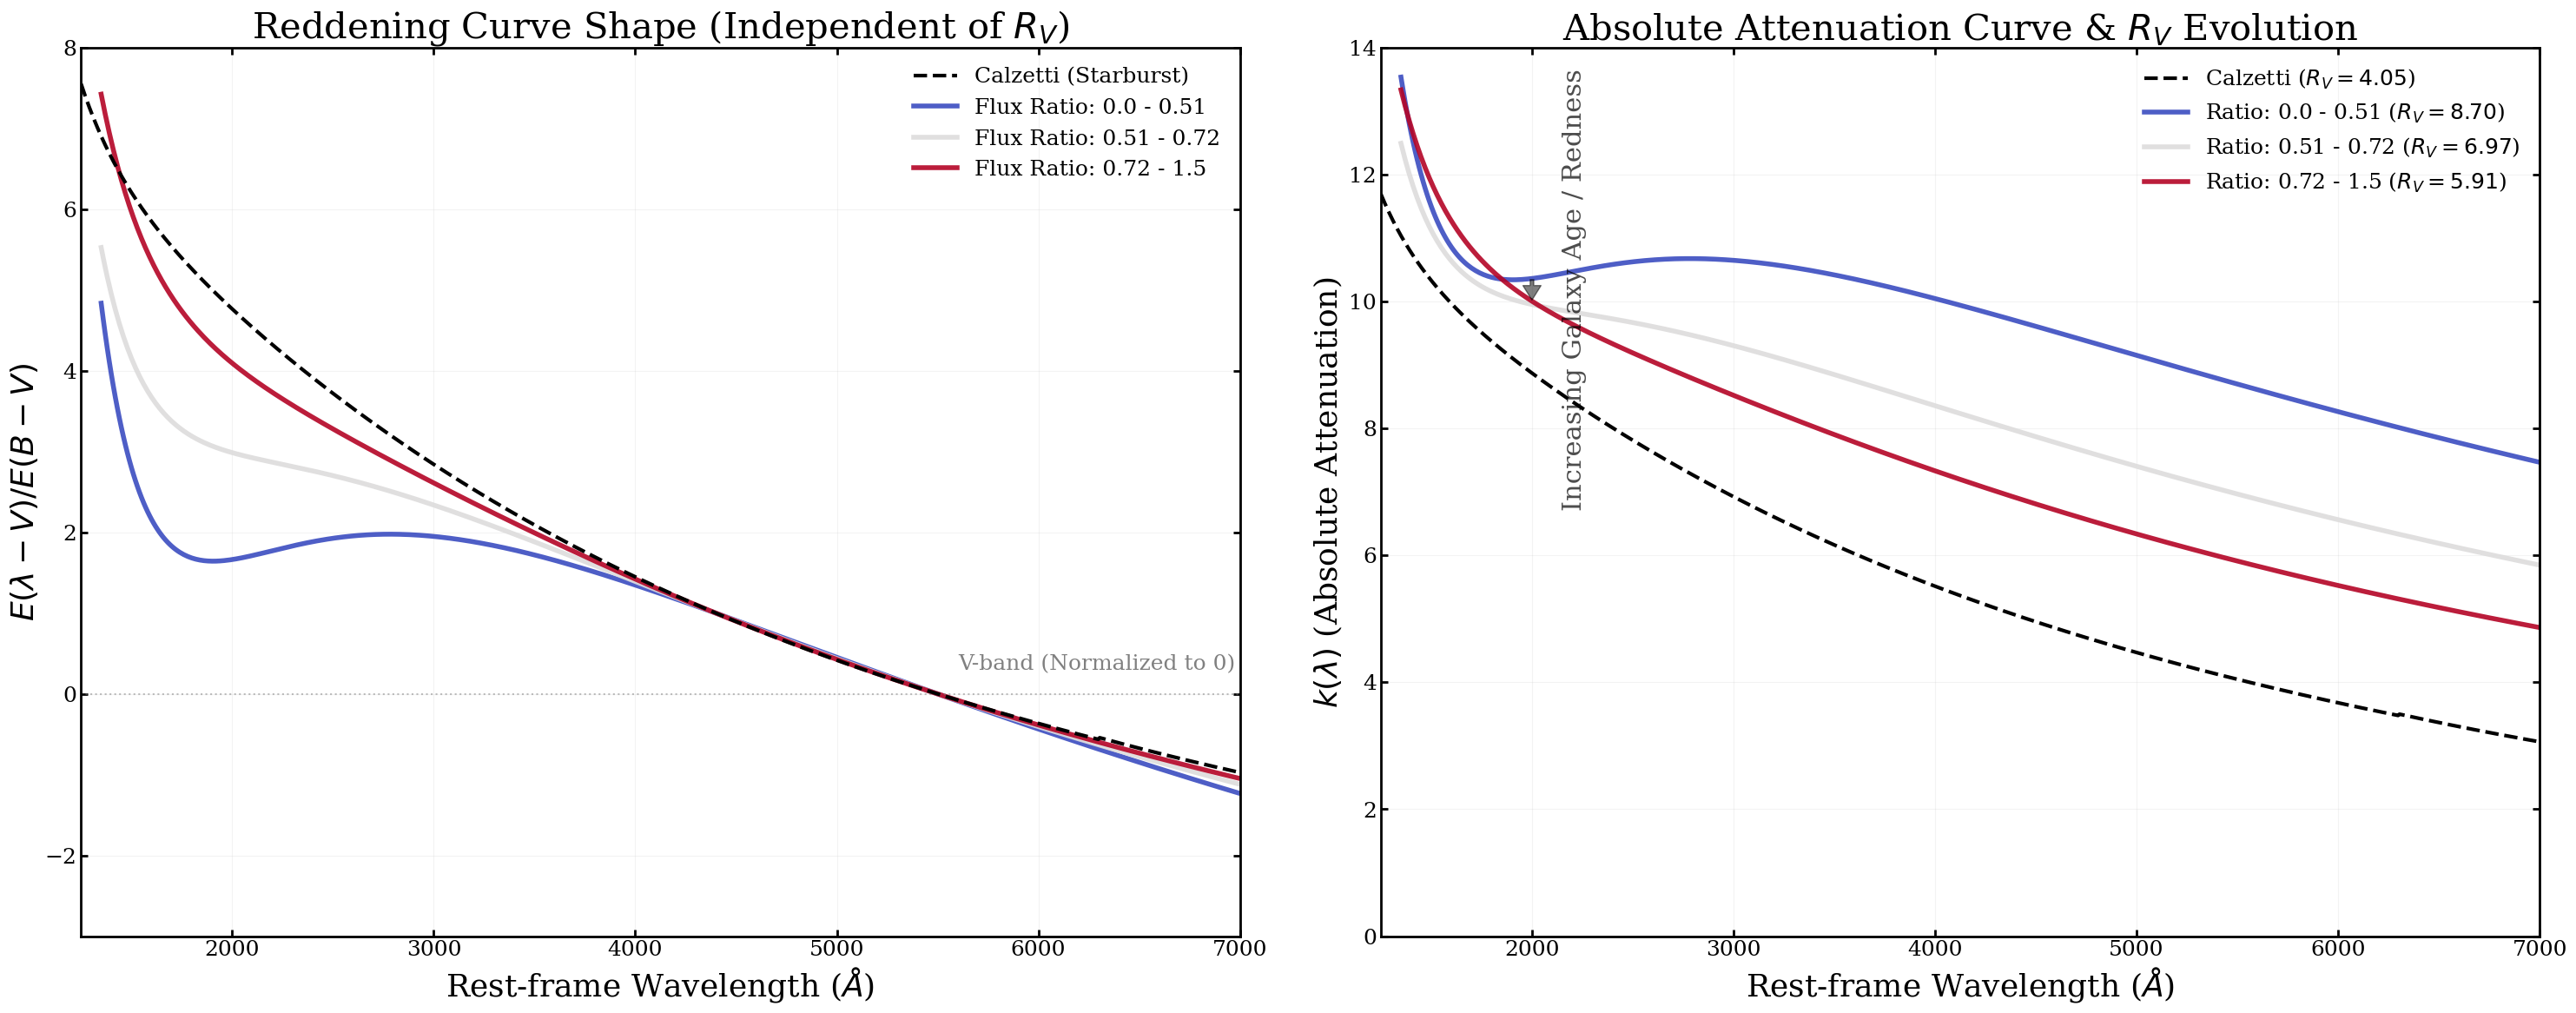

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

# ==========================================
# 1. 设置绘图风格 (Publication Quality)
# ==========================================
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.linewidth': 2,
    'xtick.major.size': 6,
    'xtick.major.width': 2,
    'ytick.major.size': 6,
    'ytick.major.width': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.figsize': (28, 12)
})

# ==========================================
# 2. 定义核心物理函数 (无需外部依赖)
# ==========================================

def calzetti_2000_law(lam_angstroms, Rv=4.05):
    """
    Calzetti (2000) Attenuation Law k(lambda).
    """
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)

    # Range 1: 0.12um to 0.63um
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv

    # Range 2: 0.63um to 2.2um
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv

    return k

def poly_model_inverse(lam_micron, a, b, c, d):
    """
    Polynomial model based on 1/lambda.
    k(x) = a + b*x + c*x^2 + d*x^3, where x = 1/lambda(micron)
    """
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

def get_calzetti_shape_normalized(wave_angstrom):
    """
    Return shape E(l-V)/E(B-V) for Calzetti law.
    """
    k_cal = calzetti_2000_law(wave_angstrom, Rv=4.05)

    # Interpolate to find precise B and V values
    k_B = np.interp(4400, wave_angstrom, k_cal)
    k_V = np.interp(5500, wave_angstrom, k_cal)

    # Definition: (k(l) - k(V)) / (k(B) - k(V))
    # For standard Calzetti, denominator is 1.0 by definition
    return (k_cal - k_V) / (k_B - k_V)

# ==========================================
# 3. 数据处理与拟合 (Data Processing)
# ==========================================

results = []
# 生成颜色映射：从蓝色(Flux Ratio小)到红色(Flux Ratio大)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(dn_index_conditions)))

print(f"{'Bin Range':<15} | {'Measured Rv':<15} | {'Slope (Flatness)'}")
print("-" * 50)

for i in range(len(dn_index_conditions)):
    # 1. 获取数据 (假设 effective_attenuation_curve_list 存在于环境中)
    # 格式: (wavelength_array, Q_value_array)
    wave, Q_curve = effective_attenuation_curve_list[i]

    # 2. 预处理：Mask 掉发射线区域和 NaN
    mask_regions = [
        (3700, 4150), (4300, 4400), (4800, 5050),
        (5850, 5900), (6500, 6650), (6700, 6760),
        (7000, 7150), (7300, 7500)
    ]

    is_continuum = np.ones_like(wave, dtype=bool)
    for start, end in mask_regions:
        is_continuum &= ~((wave >= start) & (wave <= end))

    valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
    # 只拟合 1250A 到 8000A
    fit_mask = (wave > 1250) & (wave < 8000) & is_continuum & valid_data

    # 3. 拟合 Q(lambda)
    microns = wave / 10000.0
    try:
        popt, _ = curve_fit(poly_model_inverse, microns[fit_mask], Q_curve[fit_mask])
    except:
        print(f"Fit failed for bin {i}")
        continue

    # 4. 计算归一化因子 (Scaling Factor S)
    # 依据: k(B) - k(V) = 1
    # k = S * Q + C
    # S * (Q_B - Q_V) = 1  => S = 1 / (Q_B - Q_V)
    Q_B = poly_model_inverse(0.4400, *popt)
    Q_V = poly_model_inverse(0.5500, *popt)
    delta_tau = Q_B - Q_V
    S_factor = 1.0 / delta_tau

    # 5. 计算零点漂移 (Zero-point Shift C)
    # 依据: 强制无穷远处的消光 k(inf) = -0.8877 (匹配 Calzetti 远红端渐近线)
    # 多项式在 x=1/inf=0 处的值为 popt[0] (常数项 a)
    # k(inf) = S * Q(inf) + C = S * a + C = -0.8877
    # C = -0.8877 - S * a
    a_intercept = popt[0]
    C_shift = -0.8877 - (a_intercept * S_factor)

    # 6. 生成最终曲线
    # 为了画图平滑，使用全波长范围，不带噪声
    Q_smooth = poly_model_inverse(microns, *popt)
    k_final = Q_smooth * S_factor + C_shift

    # 7. 计算 Rv
    # Rv = k(V)
    Rv_measured = k_final[(np.abs(wave - 5500)).argmin()]

    # 8. 计算红化形状 (Reddening Curve Shape)
    # Shape = k(lambda) - Rv
    shape_curve = k_final - Rv_measured

    bin_label = f"{dn_index_conditions[i][0]} - {dn_index_conditions[i][1]}"
    print(f"{bin_label:<15} | {Rv_measured:.4f}          | {'Steep' if Rv_measured < 4 else 'Flat'}")

    results.append({
        'wave': wave,
        'k_final': k_final,
        'shape_curve': shape_curve,
        'Rv': Rv_measured,
        'label': bin_label,
        'color': colors[i]
    })

# ==========================================
# 4. 绘图 (Visualization)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
plt.subplots_adjust(wspace=0.15)

# --- 生成参考线数据 ---
x_grid = np.linspace(1250, 8000, 1000)
calzetti_shape = get_calzetti_shape_normalized(x_grid)
calzetti_k = calzetti_2000_law(x_grid, Rv=4.05)

# ------------------------------------------
# 图 1 (左): 红化形状 (Reddening Curve Shape)
# ------------------------------------------
ax0 = axes[0]

# 画参考线
ax0.plot(x_grid, calzetti_shape, color='black', linestyle='--', linewidth=3,
         label='Calzetti (Starburst)', zorder=10)

# 画各组数据
for res in results:
    mask_plot = (res['wave'] > 1250) & (res['wave'] < 7000)
    ax0.plot(res['wave'][mask_plot], res['shape_curve'][mask_plot],
             color=res['color'], linewidth=4, alpha=0.9,
             label=f"Flux Ratio: {res['label']}")

# 装饰
ax0.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=26)
ax0.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=26)
ax0.set_title(r'Reddening Curve Shape (Independent of $R_V$)', fontsize=30)
ax0.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax0.text(5600, 0.3, 'V-band (Normalized to 0)', color='gray', fontsize=18)
ax0.set_xlim(1250, 7000)
ax0.set_ylim(-3, 8)
ax0.legend(fontsize=18, loc='upper right', frameon=False)
ax0.grid(True, alpha=0.15)

# ------------------------------------------
# 图 2 (右): 绝对消光曲线 (Absolute Attenuation)
# ------------------------------------------
ax1 = axes[1]

# 画参考线
ax1.plot(x_grid, calzetti_k, color='black', linestyle='--', linewidth=3,
         label='Calzetti ($R_V=4.05$)', zorder=10)

# 画各组数据
for res in results:
    mask_plot = (res['wave'] > 1250) & (res['wave'] < 7000)
    label_str = f"Ratio: {res['label']} ($R_V={res['Rv']:.2f}$)"
    ax1.plot(res['wave'][mask_plot], res['k_final'][mask_plot],
             color=res['color'], linewidth=4, alpha=0.9,
             label=label_str)

# 装饰
ax1.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=26)
ax1.set_ylabel(r'$k(\lambda)$ (Absolute Attenuation)', fontsize=26)
ax1.set_title(r'Absolute Attenuation Curve & $R_V$ Evolution', fontsize=30)
ax1.set_xlim(1250, 7000)
ax1.set_ylim(0, 14) # 根据实际数据调整
ax1.legend(fontsize=18, loc='upper right', frameon=False)
ax1.grid(True, alpha=0.15)

# 添加演化箭头 (示意)
arrow_x = 2000
if len(results) >= 2:
    y_start = results[0]['k_final'][(np.abs(results[0]['wave'] - arrow_x)).argmin()]
    y_end = results[-1]['k_final'][(np.abs(results[-1]['wave'] - arrow_x)).argmin()]

    # 从蓝(年轻) -> 红(年老)
    ax1.annotate('', xy=(arrow_x, y_end), xytext=(arrow_x, y_start),
                 arrowprops=dict(facecolor='black', shrink=0.05, alpha=0.5, width=3, headwidth=15))
    ax1.text(arrow_x + 150, (y_start+y_end)/2, 'Increasing Galaxy Age / Redness',
             rotation=90, va='center', fontsize=22, alpha=0.7)

plt.tight_layout()
plt.savefig('Evolution_of_Attenuation_Curve_by_Flux_Ratio_Publication.pdf', bbox_inches='tight', dpi=300)
plt.show()

Bin                  | Rv         | Type
---------------------------------------------
Flux Ratio: 0.0-0.51 | 8.7244     | Flat/Grey
Flux Ratio: 0.51-0.72 | 6.9901     | Flat/Grey
Flux Ratio: 0.72-1.5 | 5.9330     | Flat/Grey


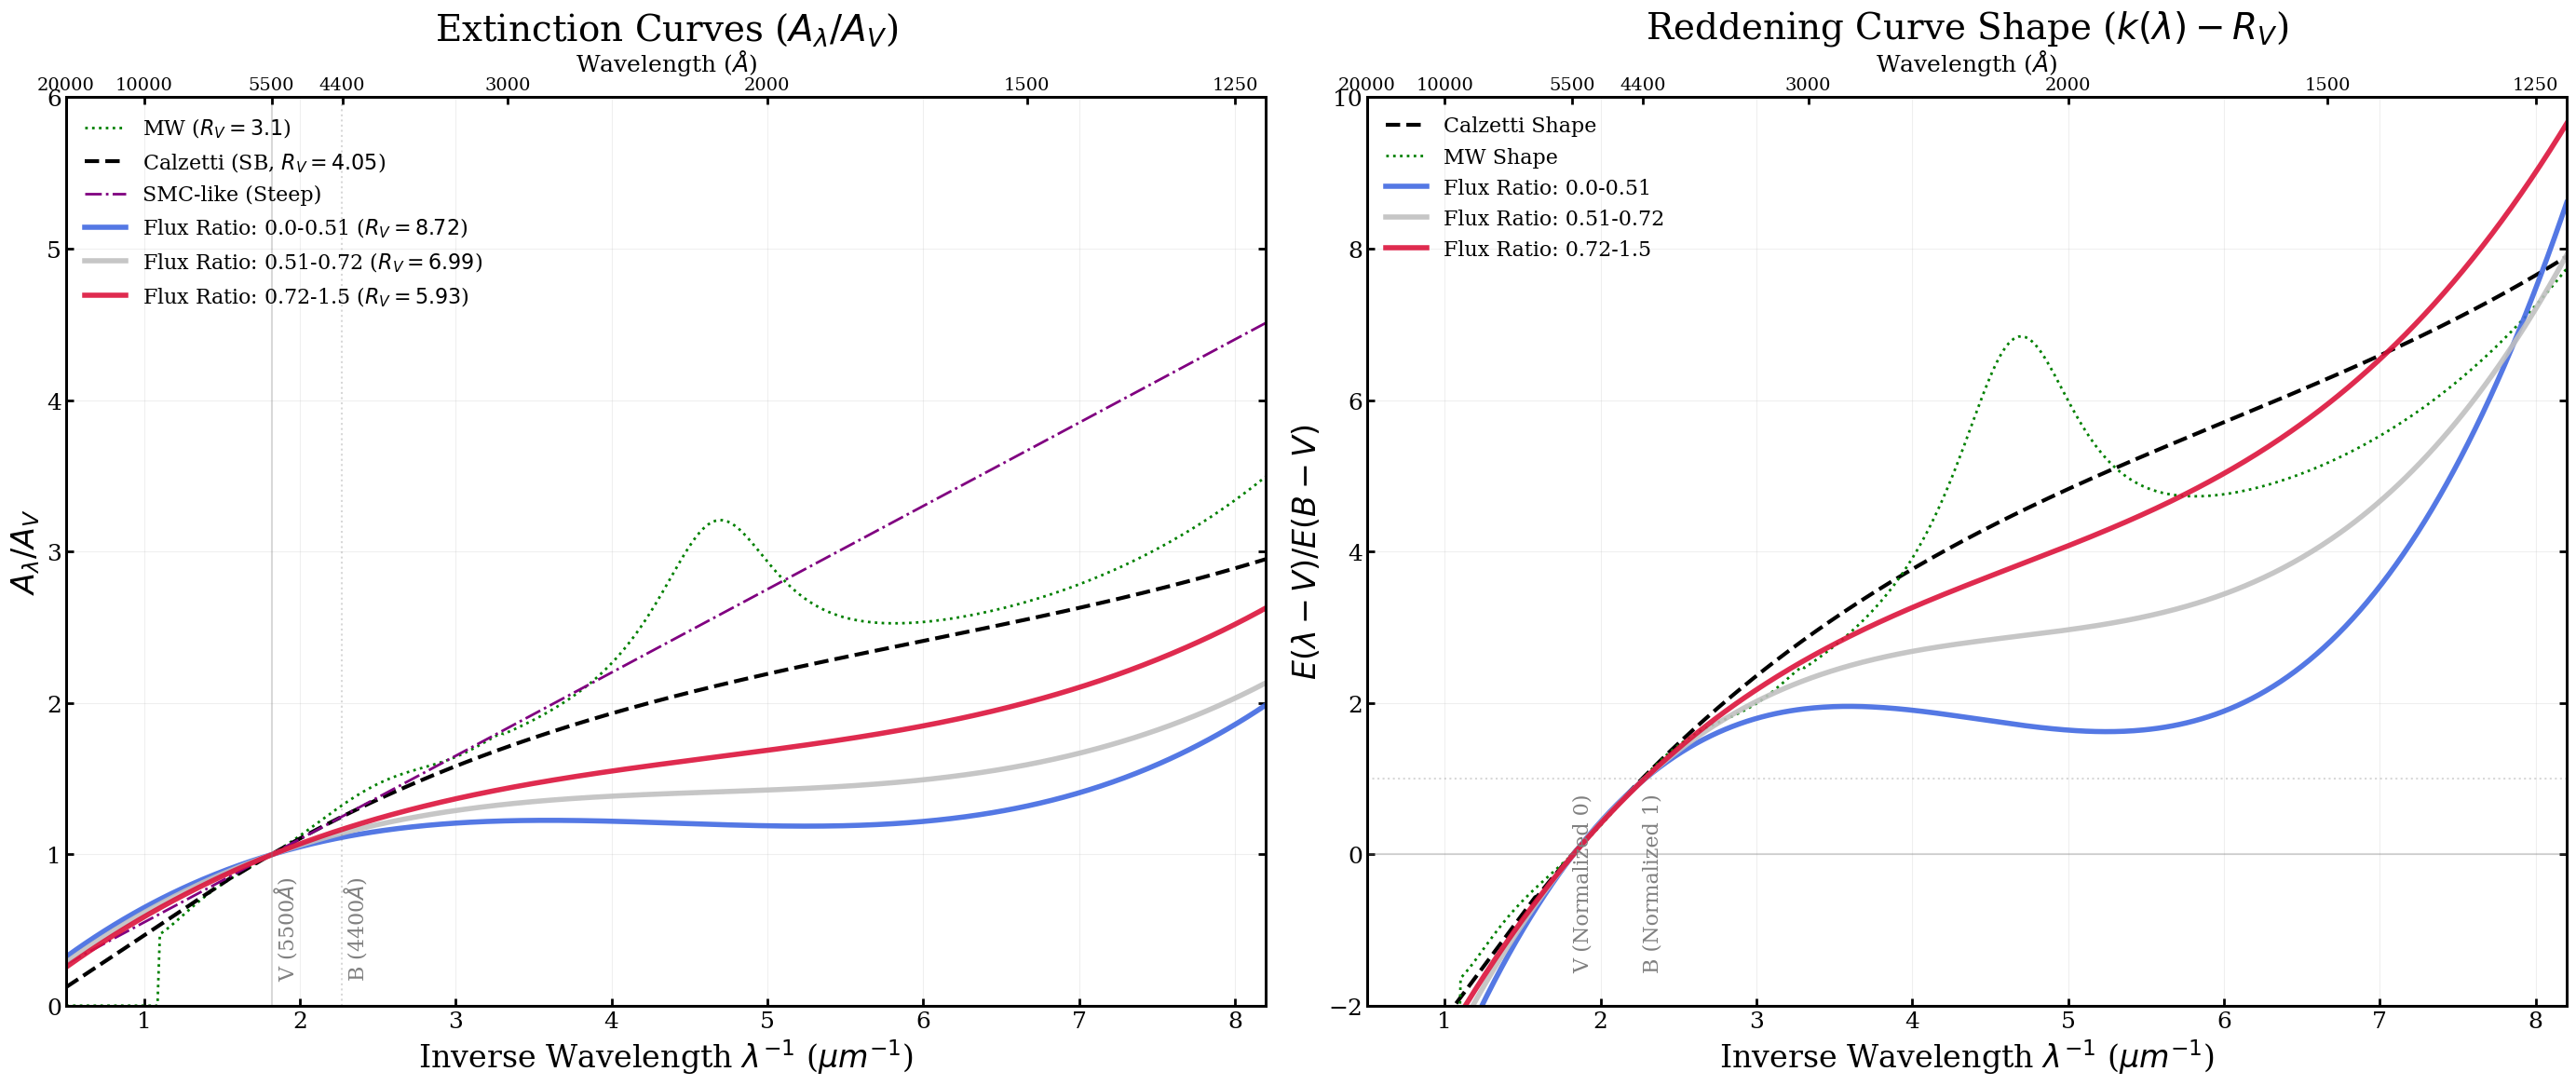

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

# ==========================================
# 1. 定义参考曲线模型 (Standard Extinction Laws)
# ==========================================
def calzetti_2000_law_Av(x, Rv=4.05):
    """Calzetti 2000: returns A_lambda / A_V based on x = 1/lambda(um)"""
    lam_um = 1.0 / x
    k = np.zeros_like(x)
    # Range 1: 0.12um to 0.63um
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv
    # Range 2: 0.63um to 2.2um
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv
    return k / Rv

def ccm89_mw_Av(x, Rv=3.1):
    """Cardelli, Clayton, & Mathis (1989) MW law: returns A_lambda / A_V"""
    x = np.array(x)
    a = np.zeros_like(x); b = np.zeros_like(x)
    # Optical/NIR (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7
    # UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3; F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    F_a[X < 5.9] = 0; F_b[X < 5.9] = 0
    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b
    return a + b / Rv

def smc_pei92_Av(x):
    """SMC Pei (1992): returns A_lambda / A_V (Approx)"""
    # Simplified polynomial for plotting SMC-like steep curve without 2175 bump
    # This matches the typical steep slope seen in literature plots
    # Normalized to A_V = 1 at x=1.82 (5500A)
    return np.exp((x - 1.82)*0.8) # Simple exponential approximation for visualization
    # Or use standard linear approx for UV:
    y = np.zeros_like(x)
    y = -1.5 + 1.35 * x  # Rough linear approximation in UV
    # Splice with optical to force 1 at V
    return np.where(x > 2, y, x * 0.55) # Crude but visualizes "Steep"

def poly_model_inverse(lam_micron, a, b, c, d):
    """k(x) = a + b*x + c*x^2 + d*x^3"""
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# ==========================================
# 2. 数据处理与计算
# ==========================================
# 假设 effective_attenuation_curve_list 和 dn_index_conditions 已经存在

results_inv = []
colors = ['royalblue', 'silver', 'crimson'] # Blue (Young), Grey (Mid), Red (Old)

print(f"{'Bin':<20} | {'Rv':<10} | {'Type'}")
print("-" * 45)

for i in range(len(dn_index_conditions)):
    wave, Q_curve = effective_attenuation_curve_list[i]
    microns = wave / 10000.0

    # Masking
    mask_regions = [(3700, 4150), (4300, 4400), (4800, 5050), (5850, 5900),
                    (6500, 6650), (6700, 6760), (7000, 7150), (7300, 7500)]
    is_valid = np.isfinite(Q_curve) & np.isfinite(wave)
    for start, end in mask_regions:
        is_valid &= ~((wave >= start) & (wave <= end))
    fit_mask = (wave > 1250) & (wave < 8000) & is_valid

    # Fitting Q(x)
    popt, _ = curve_fit(poly_model_inverse, microns[fit_mask], Q_curve[fit_mask])

    # Calculating S and C (Zero-point matching Calzetti far-IR)
    Q_B = poly_model_inverse(0.4400, *popt)
    Q_V = poly_model_inverse(0.5500, *popt)
    S_factor = 1.0 / (Q_B - Q_V)

    a_intercept = popt[0]
    C_shift = -0.8877 - (a_intercept * S_factor)

    # Generating smooth curve for plotting
    # Grid in 1/lambda from 0.5 to 8.2 (1200A to 20000A)
    x_grid_plot = np.linspace(0.5, 8.2, 500)
    lam_grid_micron = 1.0 / x_grid_plot

    Q_smooth = poly_model_inverse(lam_grid_micron, *popt)
    k_final = Q_smooth * S_factor + C_shift

    # Calculate Rv = k(V) (V-band is at x ~ 1.82)
    Rv_measured = k_final[(np.abs(x_grid_plot - 1.82)).argmin()]

    results_inv.append({
        'x': x_grid_plot,
        'k': k_final,
        'Rv': Rv_measured,
        'label': f"Flux Ratio: {dn_index_conditions[i][0]}-{dn_index_conditions[i][1]}",
        'color': colors[i]
    })

    print(f"{results_inv[-1]['label']:<20} | {Rv_measured:.4f}     | {'Flat/Grey' if Rv_measured > 5 else 'Steep/Calzetti'}")

# ==========================================
# 3. 绘图 (Standard Extinction Plots)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(28, 12))
plt.subplots_adjust(wspace=0.15)

# X-axis definition
x_ref = np.linspace(0.5, 8.2, 500)

# --- Plot 1: A_lambda / A_V (Total Extinction) ---
ax0 = axes[0]

# Reference Curves
ax0.plot(x_ref, ccm89_mw_Av(x_ref), color='green', linestyle=':', linewidth=2, label='MW ($R_V=3.1$)')
ax0.plot(x_ref, calzetti_2000_law_Av(x_ref, Rv=4.05), color='black', linestyle='--', linewidth=3, label='Calzetti (SB, $R_V=4.05$)')
# SMC approximation for visual comparison
ax0.plot(x_ref, x_ref*0.55, color='purple', linestyle='-.', linewidth=2, label='SMC-like (Steep)')

# Data Curves
for res in results_inv:
    # A_lambda / A_V = k(lambda) / Rv
    y_plot = res['k'] / res['Rv']
    ax0.plot(res['x'], y_plot, color=res['color'], linewidth=4, alpha=0.9,
             label=f"{res['label']} ($R_V={res['Rv']:.2f}$)")

# Annotations
ax0.axvline(1.82, color='gray', linestyle='-', alpha=0.3) # V band
ax0.text(1.82, 0.2, 'V (5500$\AA$)', rotation=90, color='gray', fontsize=16)
ax0.axvline(2.27, color='gray', linestyle=':', alpha=0.3) # B band
ax0.text(2.27, 0.2, 'B (4400$\AA$)', rotation=90, color='gray', fontsize=16)

ax0.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=24)
ax0.set_ylabel(r'$A_\lambda / A_V$', fontsize=24)
ax0.set_title(r'Extinction Curves ($A_\lambda / A_V$)', fontsize=28)
ax0.set_xlim(0.5, 8.2)
ax0.set_ylim(0, 6) # Adjusted for A/Av
ax0.legend(fontsize=16, loc='upper left', frameon=False)
ax0.grid(True, alpha=0.2)

# --- Plot 2: E(lambda-V) / E(B-V) (Reddening Shape) ---
ax1 = axes[1]

# Reference Curves (Shape only)
# Calzetti Shape: k(l) - Rv
k_cal = calzetti_2000_law_Av(x_ref, Rv=4.05) * 4.05
y_cal_shape = (k_cal - 4.05) / 1.0 # Normalized by E(B-V)=1
ax1.plot(x_ref, y_cal_shape, color='black', linestyle='--', linewidth=3, label='Calzetti Shape')

# MW Shape (Approx)
a_mw = ccm89_mw_Av(x_ref, Rv=3.1)
y_mw_shape = (a_mw * 3.1 - 3.1)
ax1.plot(x_ref, y_mw_shape, color='green', linestyle=':', linewidth=2, label='MW Shape')

# Data Curves
for res in results_inv:
    # E(l-V)/E(B-V) = k(lambda) - Rv
    y_plot = res['k'] - res['Rv']
    ax1.plot(res['x'], y_plot, color=res['color'], linewidth=4, alpha=0.9,
             label=f"{res['label']}")

# Annotations
ax1.axhline(0, color='gray', linestyle='-', alpha=0.3) # V band
ax1.axhline(1, color='gray', linestyle=':', alpha=0.3) # B band
ax1.text(1.82, -1.5, 'V (Normalized 0)', rotation=90, color='gray', fontsize=16)
ax1.text(2.27, -1.5, 'B (Normalized 1)', rotation=90, color='gray', fontsize=16)

ax1.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=24)
ax1.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=24)
ax1.set_title(r'Reddening Curve Shape ($k(\lambda) - R_V$)', fontsize=28)
ax1.set_xlim(0.5, 8.2)
ax1.set_ylim(-2, 10)
ax1.legend(fontsize=16, loc='upper left', frameon=False)
ax1.grid(True, alpha=0.2)

# --- Add Top Axis (Wavelength in Angstroms) ---
for ax in axes:
    ax2 = ax.twiny()
    ax2_ticks = np.array([20000, 10000, 5500, 4400, 3000, 2000, 1500, 1250])
    ax2_tick_locs = 10000.0 / ax2_ticks
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(ax2_tick_locs)
    ax2.set_xticklabels([f"{int(t)}" for t in ax2_ticks], fontsize=14)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=18)

plt.tight_layout()
plt.savefig('Extinction_Curve_vs_Inverse_Lambda_Standard.pdf', bbox_inches='tight', dpi=300)
plt.show()

Bin                  | Rv         | Type
---------------------------------------------
Flux Ratio: 0.0-0.51 | 6.2339     | Flat/Grey
Flux Ratio: 0.51-0.72 | 4.3306     | Steep/Calzetti
Flux Ratio: 0.72-1.5 | 3.9227     | Steep/Calzetti


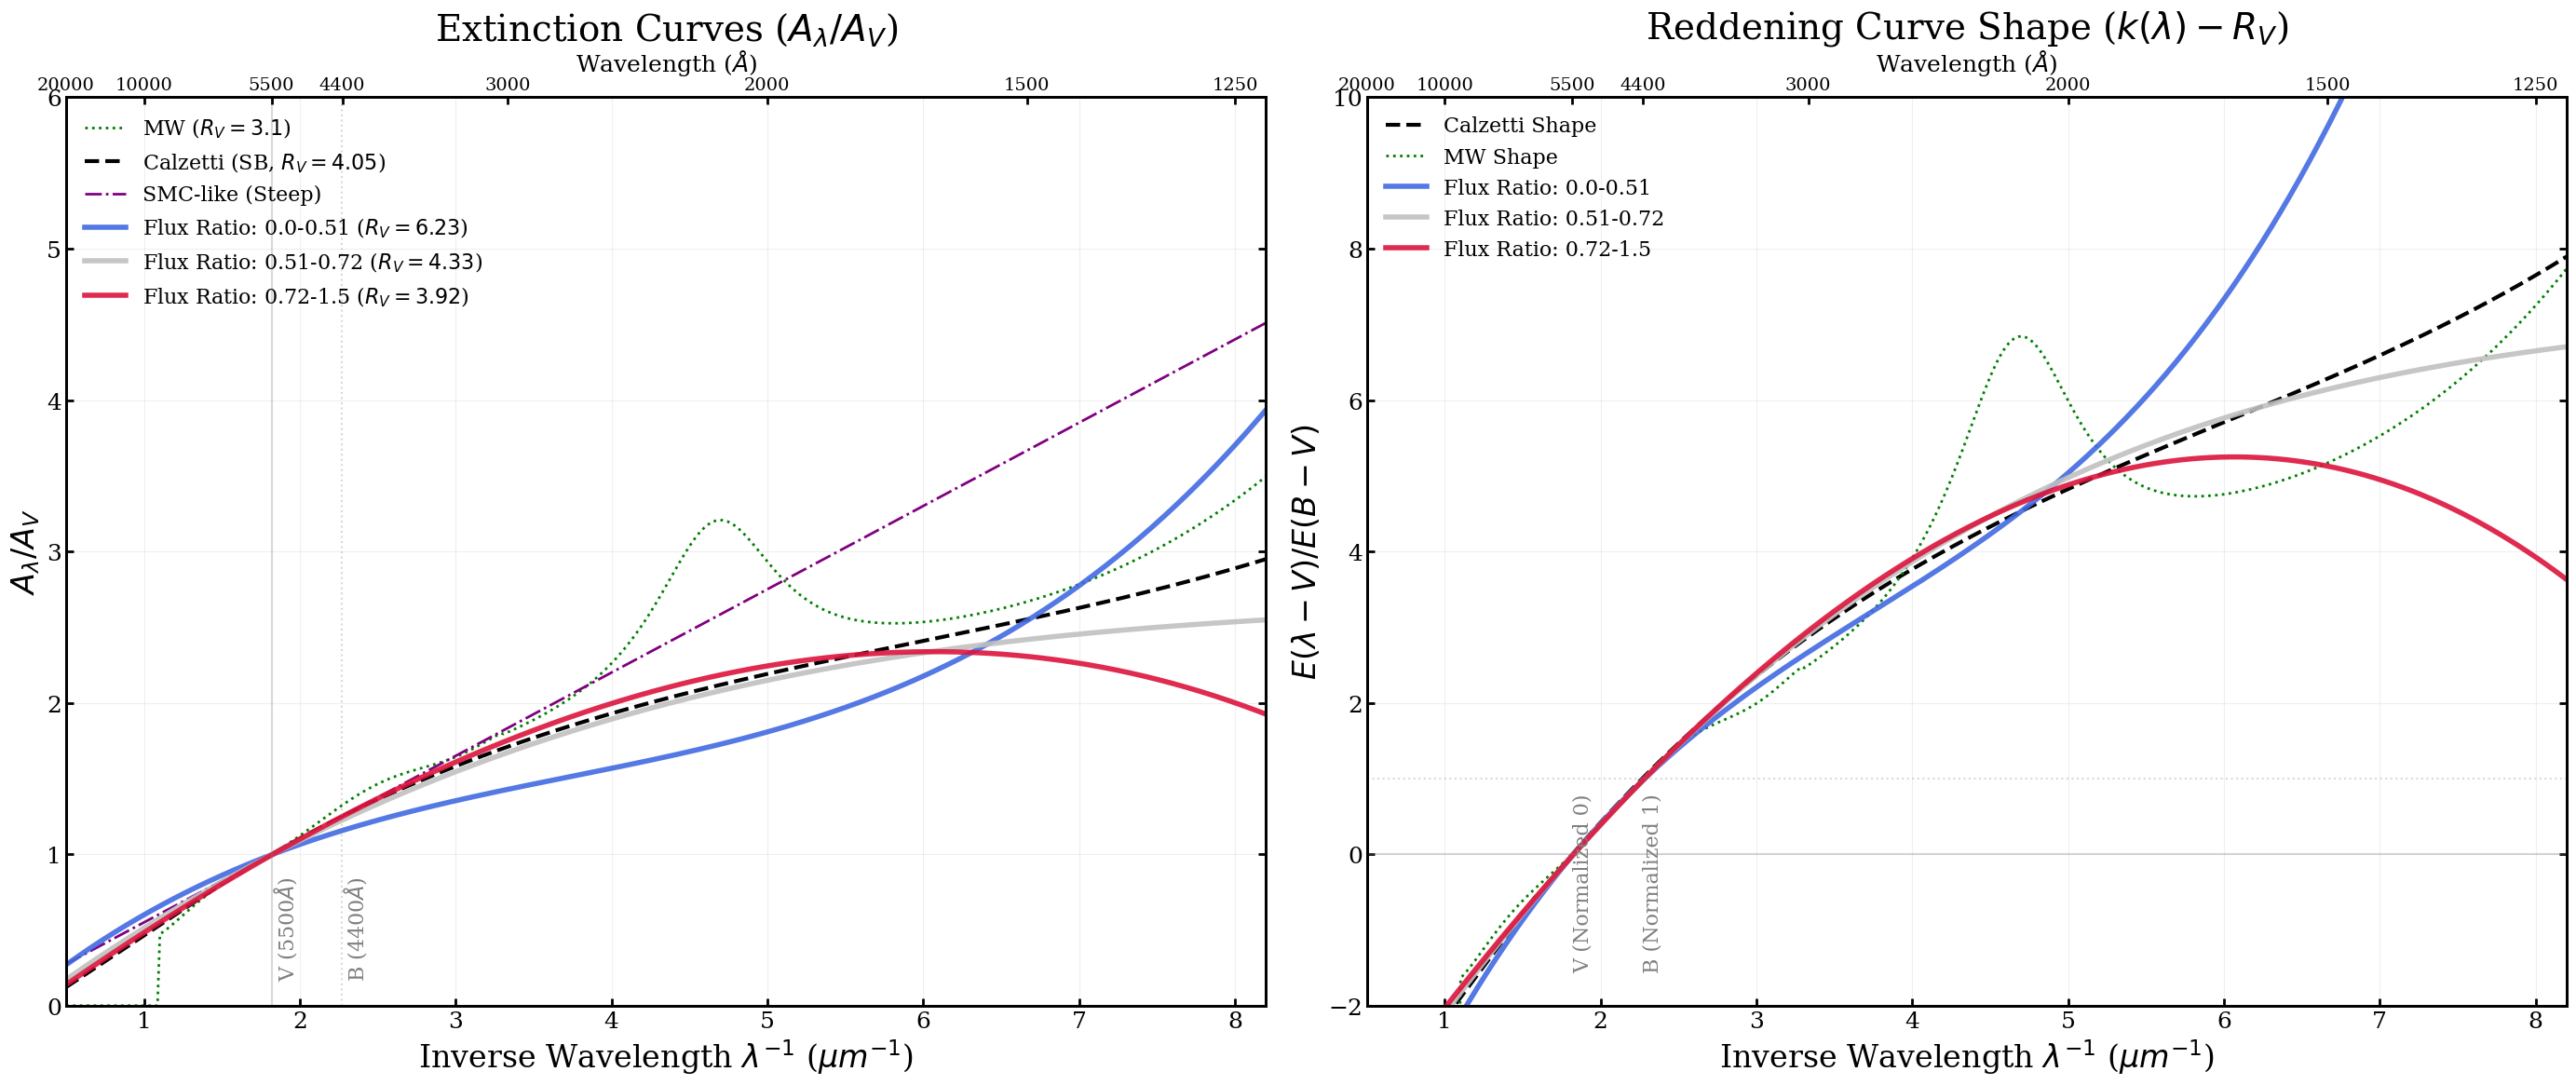

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

# ==========================================
# 1. 定义参考曲线模型 (Standard Extinction Laws)
# ==========================================
def calzetti_2000_law_Av(x, Rv=4.05):
    """Calzetti 2000: returns A_lambda / A_V based on x = 1/lambda(um)"""
    lam_um = 1.0 / x
    k = np.zeros_like(x)
    # Range 1: 0.12um to 0.63um
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv
    # Range 2: 0.63um to 2.2um
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv
    return k / Rv

def ccm89_mw_Av(x, Rv=3.1):
    """Cardelli, Clayton, & Mathis (1989) MW law: returns A_lambda / A_V"""
    x = np.array(x)
    a = np.zeros_like(x); b = np.zeros_like(x)
    # Optical/NIR (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7
    # UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3; F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    F_a[X < 5.9] = 0; F_b[X < 5.9] = 0
    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b
    return a + b / Rv

def smc_pei92_Av(x):
    """SMC Pei (1992): returns A_lambda / A_V (Approx)"""
    # Simplified polynomial for plotting SMC-like steep curve without 2175 bump
    # This matches the typical steep slope seen in literature plots
    # Normalized to A_V = 1 at x=1.82 (5500A)
    return np.exp((x - 1.82)*0.8) # Simple exponential approximation for visualization
    # Or use standard linear approx for UV:
    y = np.zeros_like(x)
    y = -1.5 + 1.35 * x  # Rough linear approximation in UV
    # Splice with optical to force 1 at V
    return np.where(x > 2, y, x * 0.55) # Crude but visualizes "Steep"

def poly_model_inverse(lam_micron, a, b, c, d):
    """k(x) = a + b*x + c*x^2 + d*x^3"""
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# ==========================================
# 2. 数据处理与计算
# ==========================================
# 假设 effective_attenuation_curve_list 和 dn_index_conditions 已经存在

results_inv = []
colors = ['royalblue', 'silver', 'crimson'] # Blue (Young), Grey (Mid), Red (Old)

print(f"{'Bin':<20} | {'Rv':<10} | {'Type'}")
print("-" * 45)

for i in range(len(dn_index_conditions)):
    wave, Q_curve = effective_attenuation_curve_list[i]
    microns = wave / 10000.0

    # Masking
    mask_regions = [(3700, 4150), (4300, 4400), (4800, 5050), (5850, 5900),
                    (6500, 6650), (6700, 6760), (7000, 7150), (7300, 7500)]
    is_valid = np.isfinite(Q_curve) & np.isfinite(wave)
    for start, end in mask_regions:
        is_valid &= ~((wave >= start) & (wave <= end))
    fit_mask = (wave > 1250) & (wave < 8000) & is_valid

    # Fitting Q(x)
    popt, _ = curve_fit(poly_model_inverse, microns[fit_mask], Q_curve[fit_mask])

    # Calculating S and C (Zero-point matching Calzetti far-IR)
    Q_B = poly_model_inverse(0.4400, *popt)
    Q_V = poly_model_inverse(0.5500, *popt)
    S_factor = 1.0 / (Q_B - Q_V)

    a_intercept = popt[0]
    C_shift = -0.8877 - (a_intercept * S_factor)

    # Generating smooth curve for plotting
    # Grid in 1/lambda from 0.5 to 8.2 (1200A to 20000A)
    x_grid_plot = np.linspace(0.5, 8.2, 500)
    lam_grid_micron = 1.0 / x_grid_plot

    Q_smooth = poly_model_inverse(lam_grid_micron, *popt)
    k_final = Q_smooth * S_factor + C_shift

    # Calculate Rv = k(V) (V-band is at x ~ 1.82)
    Rv_measured = k_final[(np.abs(x_grid_plot - 1.82)).argmin()]

    results_inv.append({
        'x': x_grid_plot,
        'k': k_final,
        'Rv': Rv_measured,
        'label': f"Flux Ratio: {dn_index_conditions[i][0]}-{dn_index_conditions[i][1]}",
        'color': colors[i]
    })

    print(f"{results_inv[-1]['label']:<20} | {Rv_measured:.4f}     | {'Flat/Grey' if Rv_measured > 5 else 'Steep/Calzetti'}")

# ==========================================
# 3. 绘图 (Standard Extinction Plots)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(28, 12))
plt.subplots_adjust(wspace=0.15)

# X-axis definition
x_ref = np.linspace(0.5, 8.2, 500)

# --- Plot 1: A_lambda / A_V (Total Extinction) ---
ax0 = axes[0]

# Reference Curves
ax0.plot(x_ref, ccm89_mw_Av(x_ref), color='green', linestyle=':', linewidth=2, label='MW ($R_V=3.1$)')
ax0.plot(x_ref, calzetti_2000_law_Av(x_ref, Rv=4.05), color='black', linestyle='--', linewidth=3, label='Calzetti (SB, $R_V=4.05$)')
# SMC approximation for visual comparison
ax0.plot(x_ref, x_ref*0.55, color='purple', linestyle='-.', linewidth=2, label='SMC-like (Steep)')

# Data Curves
for res in results_inv:
    # A_lambda / A_V = k(lambda) / Rv
    y_plot = res['k'] / res['Rv']
    ax0.plot(res['x'], y_plot, color=res['color'], linewidth=4, alpha=0.9,
             label=f"{res['label']} ($R_V={res['Rv']:.2f}$)")

# Annotations
ax0.axvline(1.82, color='gray', linestyle='-', alpha=0.3) # V band
ax0.text(1.82, 0.2, 'V (5500$\AA$)', rotation=90, color='gray', fontsize=16)
ax0.axvline(2.27, color='gray', linestyle=':', alpha=0.3) # B band
ax0.text(2.27, 0.2, 'B (4400$\AA$)', rotation=90, color='gray', fontsize=16)

ax0.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=24)
ax0.set_ylabel(r'$A_\lambda / A_V$', fontsize=24)
ax0.set_title(r'Extinction Curves ($A_\lambda / A_V$)', fontsize=28)
ax0.set_xlim(0.5, 8.2)
ax0.set_ylim(0, 6) # Adjusted for A/Av
ax0.legend(fontsize=16, loc='upper left', frameon=False)
ax0.grid(True, alpha=0.2)

# --- Plot 2: E(lambda-V) / E(B-V) (Reddening Shape) ---
ax1 = axes[1]

# Reference Curves (Shape only)
# Calzetti Shape: k(l) - Rv
k_cal = calzetti_2000_law_Av(x_ref, Rv=4.05) * 4.05
y_cal_shape = (k_cal - 4.05) / 1.0 # Normalized by E(B-V)=1
ax1.plot(x_ref, y_cal_shape, color='black', linestyle='--', linewidth=3, label='Calzetti Shape')

# MW Shape (Approx)
a_mw = ccm89_mw_Av(x_ref, Rv=3.1)
y_mw_shape = (a_mw * 3.1 - 3.1)
ax1.plot(x_ref, y_mw_shape, color='green', linestyle=':', linewidth=2, label='MW Shape')

# Data Curves
for res in results_inv:
    # E(l-V)/E(B-V) = k(lambda) - Rv
    y_plot = res['k'] - res['Rv']
    ax1.plot(res['x'], y_plot, color=res['color'], linewidth=4, alpha=0.9,
             label=f"{res['label']}")

# Annotations
ax1.axhline(0, color='gray', linestyle='-', alpha=0.3) # V band
ax1.axhline(1, color='gray', linestyle=':', alpha=0.3) # B band
ax1.text(1.82, -1.5, 'V (Normalized 0)', rotation=90, color='gray', fontsize=16)
ax1.text(2.27, -1.5, 'B (Normalized 1)', rotation=90, color='gray', fontsize=16)

ax1.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=24)
ax1.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=24)
ax1.set_title(r'Reddening Curve Shape ($k(\lambda) - R_V$)', fontsize=28)
ax1.set_xlim(0.5, 8.2)
ax1.set_ylim(-2, 10)
ax1.legend(fontsize=16, loc='upper left', frameon=False)
ax1.grid(True, alpha=0.2)

# --- Add Top Axis (Wavelength in Angstroms) ---
for ax in axes:
    ax2 = ax.twiny()
    ax2_ticks = np.array([20000, 10000, 5500, 4400, 3000, 2000, 1500, 1250])
    ax2_tick_locs = 10000.0 / ax2_ticks
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(ax2_tick_locs)
    ax2.set_xticklabels([f"{int(t)}" for t in ax2_ticks], fontsize=14)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=18)

plt.tight_layout()
plt.savefig('Extinction_Curve_vs_Inverse_Lambda_Standard.pdf', bbox_inches='tight', dpi=300)
plt.show()

Loading and Stacking All Spectra...
Processing Reference Spectrum (Masking + Interpolation + SG Smoothing)...


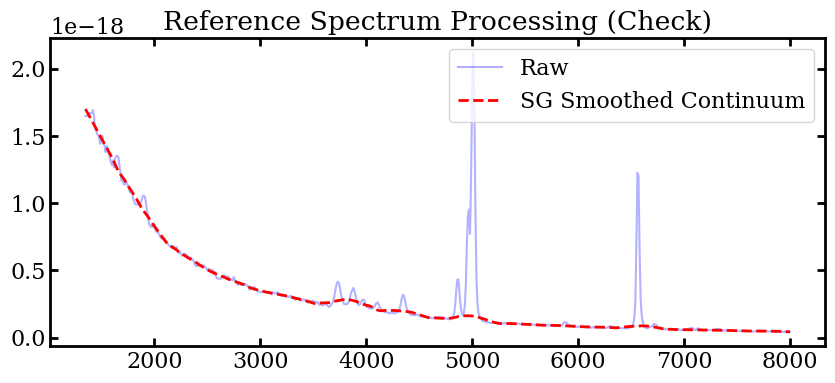

Measured Total Sample Rv: 5.3691


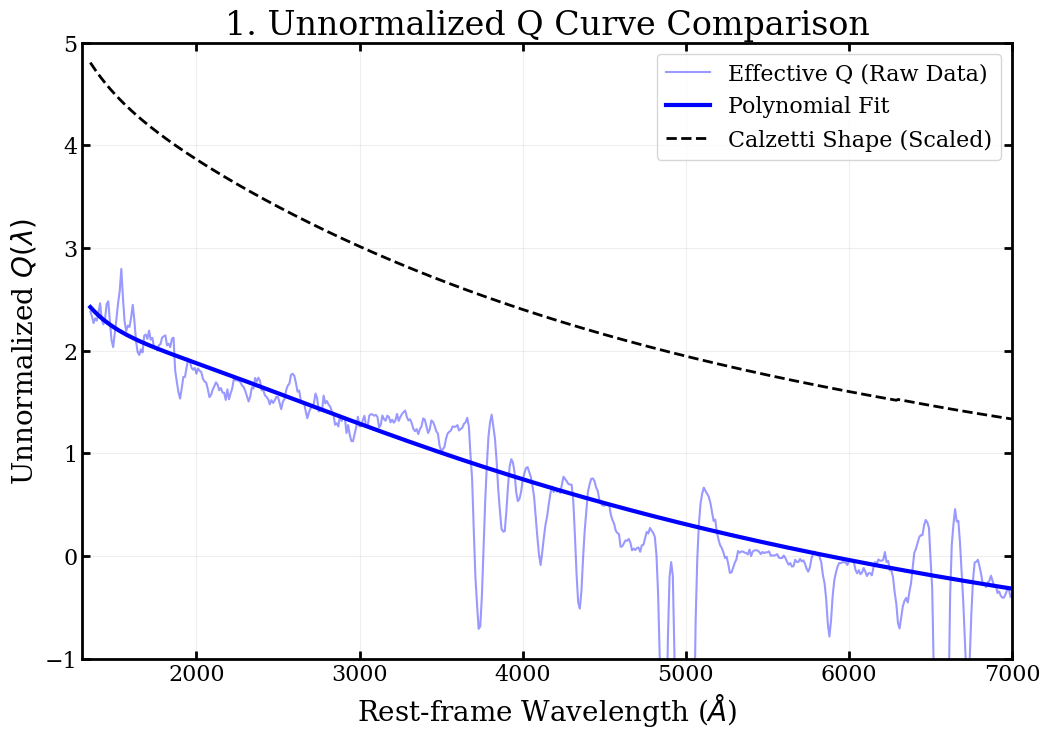

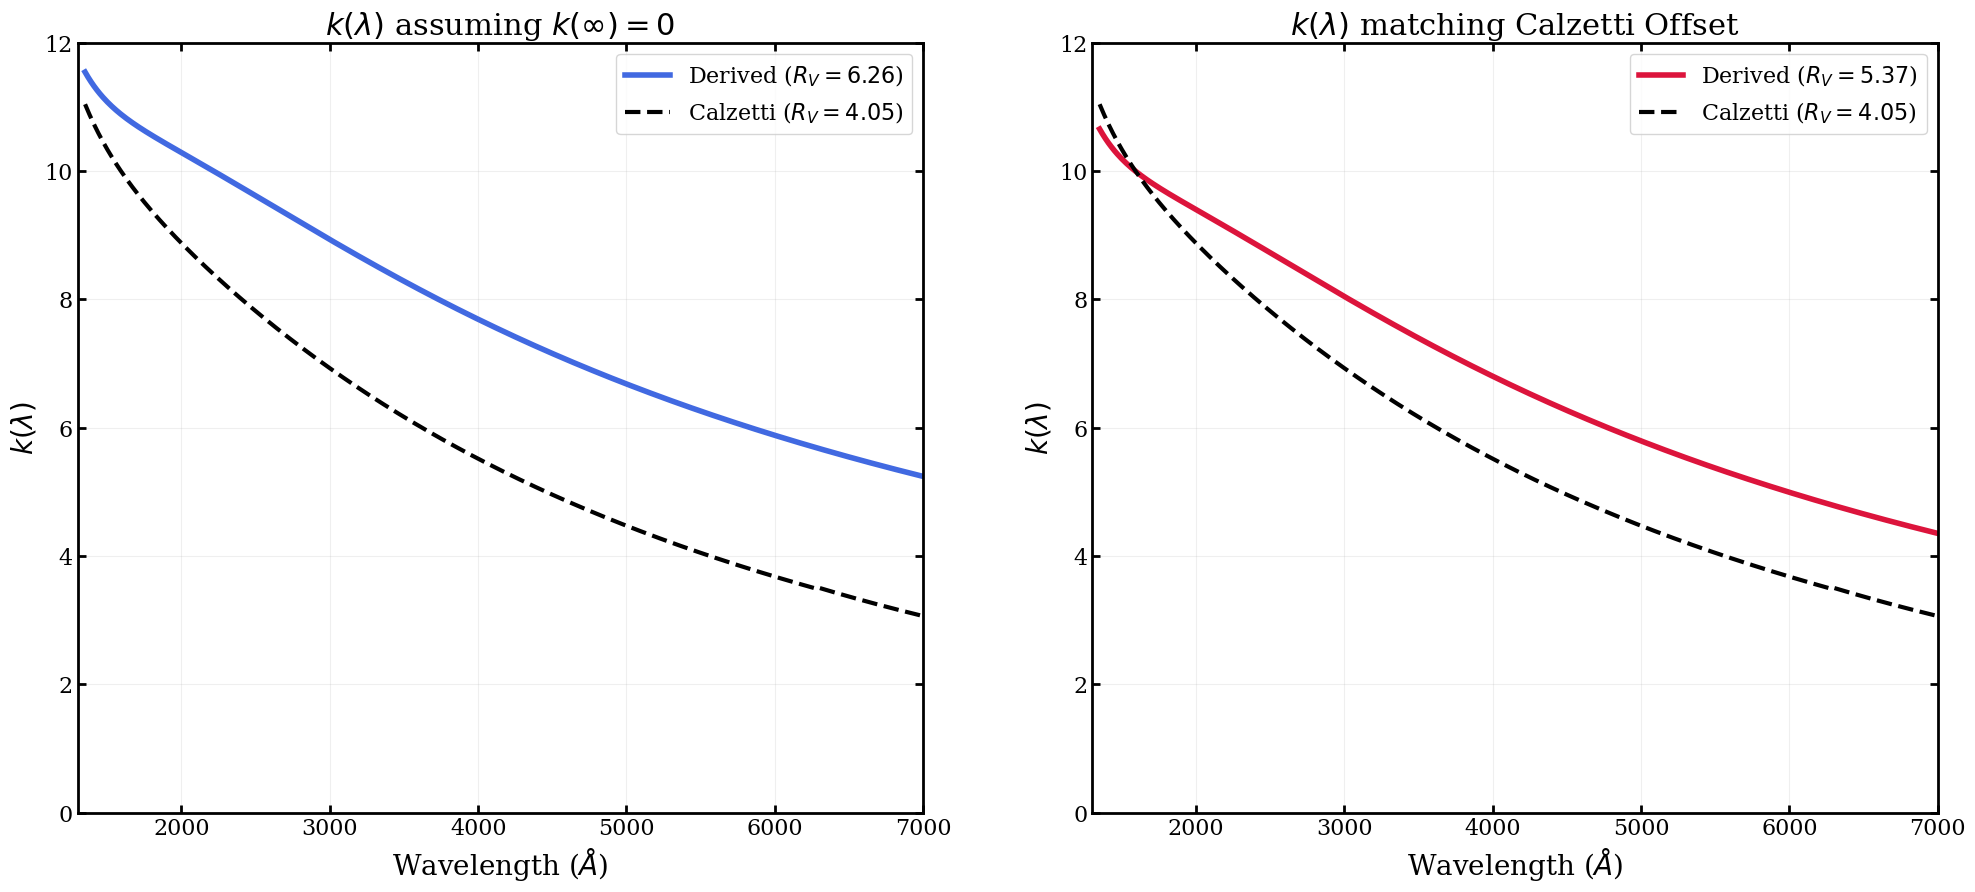

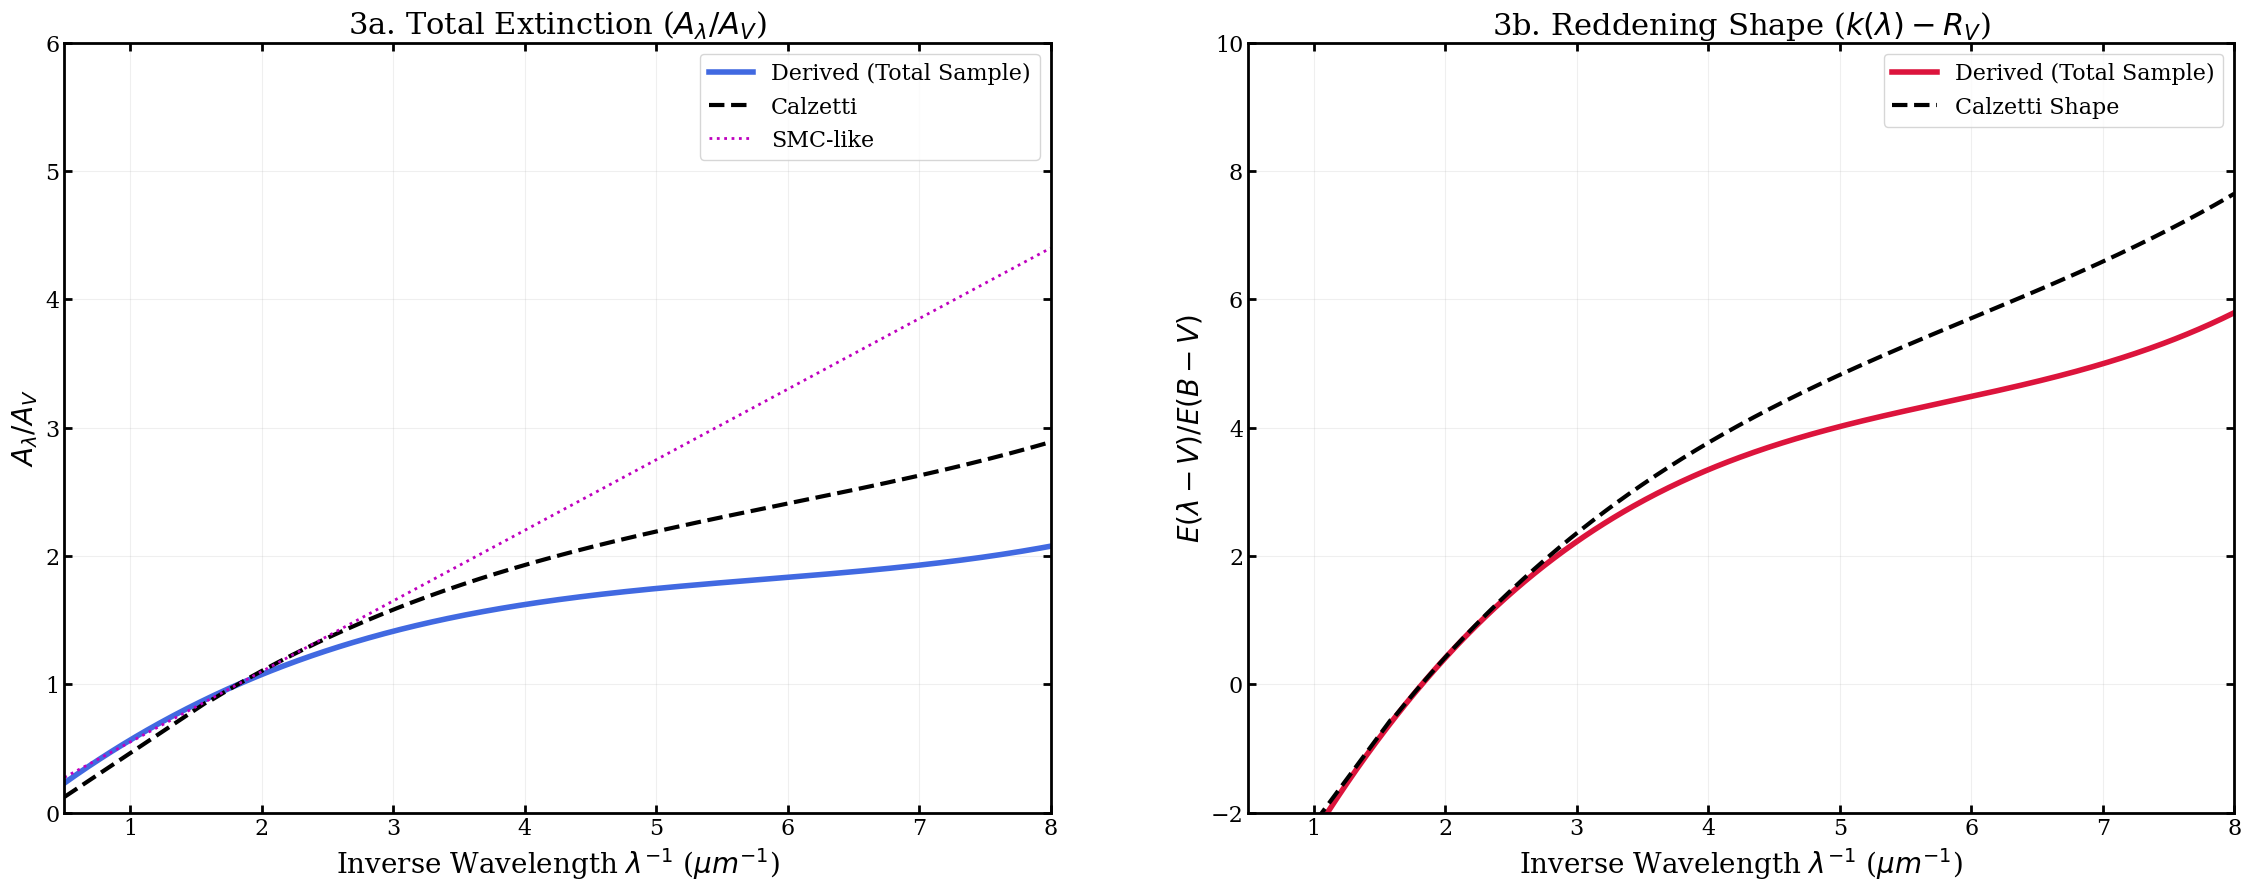

In [20]:
import numpy as np
import pandas as pd
import FunctionLib as FL
import astropy.units as u
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 0. 绘图风格与函数定义
# ==========================================
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 16,
    'axes.linewidth': 2,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'figure.figsize': (25, 8)
})

def poly_model_inverse(lam_micron, a, b, c, d):
    """k(x) = a + b*x + c*x^2 + d*x^3, x=1/lambda"""
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

def calzetti_2000_law(lam_angstroms, Rv=4.05):
    """Standard Calzetti k(lambda)"""
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

# ==========================================
# 1. 数据加载与堆叠 (全样本)
# ==========================================
DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl('./DJAV4.2Catalog.pkl')

# 尘埃分组 (Balmer Decrement)
group_conditions = [(-0.2, 0.02), (0.02, 0.10), (0.10, 0.2), (0.2, 0.3), (0.3, 0.40), (0.40, 0.6)]
def group_condition_func(bd):
    for i, (l, h) in enumerate(group_conditions):
        if l < bd <= h: return i
    return -1

averagers = {i: FL.SpectrumAverager() for i in range(7)}
group_decs = {i: [] for i in range(7)}

print("Loading and Stacking All Spectra...")

# 遍历全样本 (不按 Flux Ratio 筛选)
for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
    if not entry['sample_flag']: continue
    try:
        lines = entry['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']
        bd = np.log(lines['halpha_flux'] / lines['hbeta_flux'] / 2.86)
        g_idx = group_condition_func(bd)

        if g_idx != -1:
            averagers[g_idx].load_spectrum_catalog([surveyid_subid], DJAv4Catalog, FL.Load_Spectrum_From_Fits)
            group_decs[g_idx].append(bd)
    except: continue

# 计算堆叠谱 & 平均 BD
mean_decs = {}
invalid_averager = np.zeros(7, dtype=bool)

for i in range(7):
    if len(group_decs[i]) == 0:
        invalid_averager[i] = True
        mean_decs[i] = 0
        continue

    mean_decs[i] = np.mean(group_decs[i])
    try:
        averagers[i].create_common_wavelength_grid(wavelength_range=(1350, 8000), grid_size=10)
        averagers[i].interpolate_spectra('linear')
        averagers[i].spectrum_normalization_within_range((5250, 5750), 1e-19)
        averagers[i].compute_average_spectrum(method='median', ignore_nan=True)
    except:
        invalid_averager[i] = True

# 强制基准
mean_decs[0] = 0.0

# ==========================================
# 2. 处理 Reference (Group 0) - SG 平滑策略
# ==========================================
print("Processing Reference Spectrum (Masking + Interpolation + SG Smoothing)...")

wave_0 = averagers[0].common_wavelength
flux_0_raw = averagers[0].average_flux.copy()

# A. 定义 Mask (覆盖主要发射线)
mask_regions = [
    (1200, 1260), (1530, 1560), (1900, 1920),
    (3700, 3750), (3860, 3900), (3950, 3980), (4080, 4120), (4320, 4360),
    (4800, 5050), (5850, 5900), (6500, 6600), (6700, 6750), (7000, 7150), (7300, 7350)
]

# B. 将发射线区域置为 NaN
flux_0_masked = flux_0_raw.copy()
for (l, h) in mask_regions:
    mask_idx = (wave_0 >= l) & (wave_0 <= h)
    flux_0_masked[mask_idx] = np.nan

# C. 线性插值填补 NaN (得到粗糙连续谱)
flux_0_interp = pd.Series(flux_0_masked).interpolate(method='linear', limit_direction='both').to_numpy()

# D. SG 平滑 (得到光滑连续谱)
# 窗口长度 51, 3阶多项式
flux_0_smooth = savgol_filter(flux_0_interp, window_length=51, polyorder=3)

# 更新 Reference
ref_flux = flux_0_smooth

# (可选) 画图验证一下 Reference 处理效果
plt.figure(figsize=(10, 4))
plt.plot(wave_0, flux_0_raw, 'b-', alpha=0.3, label='Raw')
plt.plot(wave_0, ref_flux, 'r--', lw=2, label='SG Smoothed Continuum')
plt.title('Reference Spectrum Processing (Check)')
plt.legend()
plt.show()

# ==========================================
# 3. 计算 Effective Q Curve
# ==========================================
Q_list = []
weights = []

for i in range(1, 6):
    if invalid_averager[i]: continue
    target_flux = averagers[i].average_flux
    delta_tau = mean_decs[i] - mean_decs[0]

    if delta_tau > 0.02:
        with np.errstate(divide='ignore', invalid='ignore'):
            tau = -np.log(target_flux / ref_flux)
        Q = tau / delta_tau
        Q_list.append(Q)
        weights.append(delta_tau)

# 加权平均得到全样本 Q
Q_stack = np.ma.masked_invalid(np.array(Q_list))
eff_Q = np.ma.average(Q_stack, axis=0, weights=weights).filled(np.nan)

# ==========================================
# 4. 拟合 Q 并计算参数 (Rv, Scaling)
# ==========================================
# 拟合 Q(x)
microns = wave_0 / 10000.0
# Mask 掉两端和 NaN
fit_mask = (wave_0 > 1250) & (wave_0 < 8000) & np.isfinite(eff_Q)
# 再次 Mask 发射线区域以免影响拟合 Q 的趋势
for (l, h) in mask_regions:
    fit_mask &= ~((wave_0 >= l) & (wave_0 <= h))

popt, _ = curve_fit(poly_model_inverse, microns[fit_mask], eff_Q[fit_mask])

# 计算 Scaling Factor S (归一化: k(B)-k(V)=1)
Q_B = poly_model_inverse(0.44, *popt)
Q_V = poly_model_inverse(0.55, *popt)
S = 1.0 / (Q_B - Q_V)

# 计算截距 (常数项)
a_intercept = popt[0]

# 光滑的 Q 曲线用于计算
Q_poly_smooth = poly_model_inverse(microns, *popt)

# 计算 Rv (假设 Calzetti Offset)
C_calz = -0.8877 - (a_intercept * S)
k_calz_offset = S * Q_poly_smooth + C_calz
Rv_measured = k_calz_offset[(np.abs(wave_0 - 5500)).argmin()]

print(f"Measured Total Sample Rv: {Rv_measured:.4f}")

# ==========================================
# 5. 绘图 1: Unnormalized Q vs Lambda
# ==========================================
fig1, ax1 = plt.subplots(figsize=(12, 8))

# Data
ax1.plot(wave_0, eff_Q, color='blue', alpha=0.4, label='Effective Q (Raw Data)')
ax1.plot(wave_0, Q_poly_smooth, color='blue', lw=3, label='Polynomial Fit')

# Calzetti Comparison (Arbitrary Scale for Shape)
# 将 Calzetti k 缩放到 Q 的量级以便对比形状 (除以 S)
ref_calz = calzetti_2000_law(wave_0, 4.05)
ax1.plot(wave_0, ref_calz / S, 'k--', lw=2, label='Calzetti Shape (Scaled)')

ax1.set_xlim(1300, 7000)
ax1.set_ylim(-1, 5)
ax1.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
ax1.set_ylabel(r'Unnormalized $Q(\lambda)$', fontsize=20)
ax1.set_title('1. Unnormalized Q Curve Comparison', fontsize=24)
ax1.legend(fontsize=16)
ax1.grid(True, alpha=0.2)
plt.show()

# ==========================================
# 6. 绘图 2: Absolute Attenuation k(lambda) (两个假设)
# ==========================================
fig2, axes2 = plt.subplots(1, 2, figsize=(24, 10))

# --- 左图: 假设 k(inf) = 0 ---
C0 = -S * a_intercept
k_zero = S * Q_poly_smooth + C0
Rv_zero = k_zero[(np.abs(wave_0 - 5500)).argmin()]

axes2[0].plot(wave_0, k_zero, color='royalblue', lw=4, label=f'Derived ($R_V={Rv_zero:.2f}$)')
axes2[0].plot(wave_0, calzetti_2000_law(wave_0, 4.05), 'k--', lw=3, label='Calzetti ($R_V=4.05$)')

axes2[0].set_title(r'$k(\lambda)$ assuming $k(\infty)=0$', fontsize=22)
axes2[0].set_xlabel(r'Wavelength ($\AA$)', fontsize=20)
axes2[0].set_ylabel(r'$k(\lambda)$', fontsize=20)
axes2[0].set_xlim(1300, 7000)
axes2[0].set_ylim(0, 12)
axes2[0].legend(fontsize=16)
axes2[0].grid(True, alpha=0.2)

# --- 右图: 假设 Calzetti Offset ---
# k_calz_offset 已经计算过
axes2[1].plot(wave_0, k_calz_offset, color='crimson', lw=4, label=f'Derived ($R_V={Rv_measured:.2f}$)')
axes2[1].plot(wave_0, calzetti_2000_law(wave_0, 4.05), 'k--', lw=3, label='Calzetti ($R_V=4.05$)')

axes2[1].set_title(r'$k(\lambda)$ matching Calzetti Offset', fontsize=22)
axes2[1].set_xlabel(r'Wavelength ($\AA$)', fontsize=20)
axes2[1].set_ylabel(r'$k(\lambda)$', fontsize=20)
axes2[1].set_xlim(1300, 7000)
axes2[1].set_ylim(0, 12)
axes2[1].legend(fontsize=16)
axes2[1].grid(True, alpha=0.2)

plt.show()

# ==========================================
# 7. 绘图 3: Standard Plots (vs 1/lambda)
# ==========================================
fig3, axes3 = plt.subplots(1, 2, figsize=(28, 10))
x_plot = np.linspace(0.5, 8.0, 500) # 1/um
lam_plot_um = 1.0 / x_plot

# 重新计算 Grid 上的值 (使用拟合参数)
Q_grid = poly_model_inverse(lam_plot_um, *popt)
k_grid_final = S * Q_grid + C_calz # 使用 Calzetti Offset 假设
rv_grid = k_grid_final[(np.abs(x_plot - 1.82)).argmin()]

# --- 左图: A_lambda / A_V ---
axes3[0].plot(x_plot, k_grid_final / rv_grid, color='royalblue', lw=4, label='Derived (Total Sample)')
axes3[0].plot(x_plot, calzetti_2000_law(10000/x_plot)/4.05, 'k--', lw=3, label='Calzetti')
axes3[0].plot(x_plot, x_plot*0.55, 'm:', lw=2, label='SMC-like') # 简单参考

axes3[0].set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=20)
axes3[0].set_ylabel(r'$A_\lambda / A_V$', fontsize=20)
axes3[0].set_title(r'3a. Total Extinction ($A_\lambda / A_V$)', fontsize=22)
axes3[0].set_xlim(0.5, 8)
axes3[0].set_ylim(0, 6)
axes3[0].legend(fontsize=16)
axes3[0].grid(True, alpha=0.2)

# --- 右图: E(l-V) / E(B-V) ---
k_calz_ref = calzetti_2000_law(10000/x_plot)
axes3[1].plot(x_plot, k_grid_final - rv_grid, color='crimson', lw=4, label='Derived (Total Sample)')
axes3[1].plot(x_plot, k_calz_ref - 4.05, 'k--', lw=3, label='Calzetti Shape')

axes3[1].set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=20)
axes3[1].set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=20)
axes3[1].set_title(r'3b. Reddening Shape ($k(\lambda) - R_V$)', fontsize=22)
axes3[1].set_xlim(0.5, 8)
axes3[1].set_ylim(-2, 10)
axes3[1].legend(fontsize=16)
axes3[1].grid(True, alpha=0.2)

plt.show()